# 🔥 PyTorch From Scratch to LLMs — The Complete Interview Notebook

> **Goal:** By the end of this notebook, you will understand every line of PyTorch training code — from a basic `torch.Tensor` all the way to the Feed-Forward Network inside a Transformer (the backbone of GPT, BERT, Llama). No black boxes.

---

## The Universal 5-Step Training Loop (Memorize This First)

Every model — from our 2-parameter toy to a 70B LLM — trains using the **exact same** 5 steps:

| Step | What | Raw Code | Professional Code |
|:---|:---|:---|:---|
| **1. Predict** | `ŷ = f(X, θ)` | `y_hat = X @ W + b` | `y_hat = model(X)` |
| **2. Measure Error** | `L = Loss(ŷ, y)` | `loss = ((y_hat - y)**2).mean()` | `loss = criterion(y_hat, y)` |
| **3. Calc Gradients** | `∇_θ L` | `loss.backward()` | `loss.backward()` |
| **4. Update Params** | `θ -= η * ∇_θ L` | `W -= lr * W.grad` | `optimizer.step()` |
| **5. Reset Gradients** | clear for next step | `W.grad.zero_()` | `optimizer.zero_grad()` |

**This loop is universal. Steps 3-4-5 are literally identical whether you're training a 2-param model or GPT-4.**

---

## Part 1: The Core Data Structure — `torch.Tensor`

**Everything in PyTorch is a `Tensor`.** It's a multi-dimensional array — like a NumPy array — but with two superpowers:
1. It can live on the **GPU** (massively parallel computation)
2. It can participate in **Autograd** (automatic gradient computation for backprop)

**Analogy:** A Tensor is the "noun" of the PyTorch language. Before we can build any model (write a sentence), we need to master the nouns (tensors).

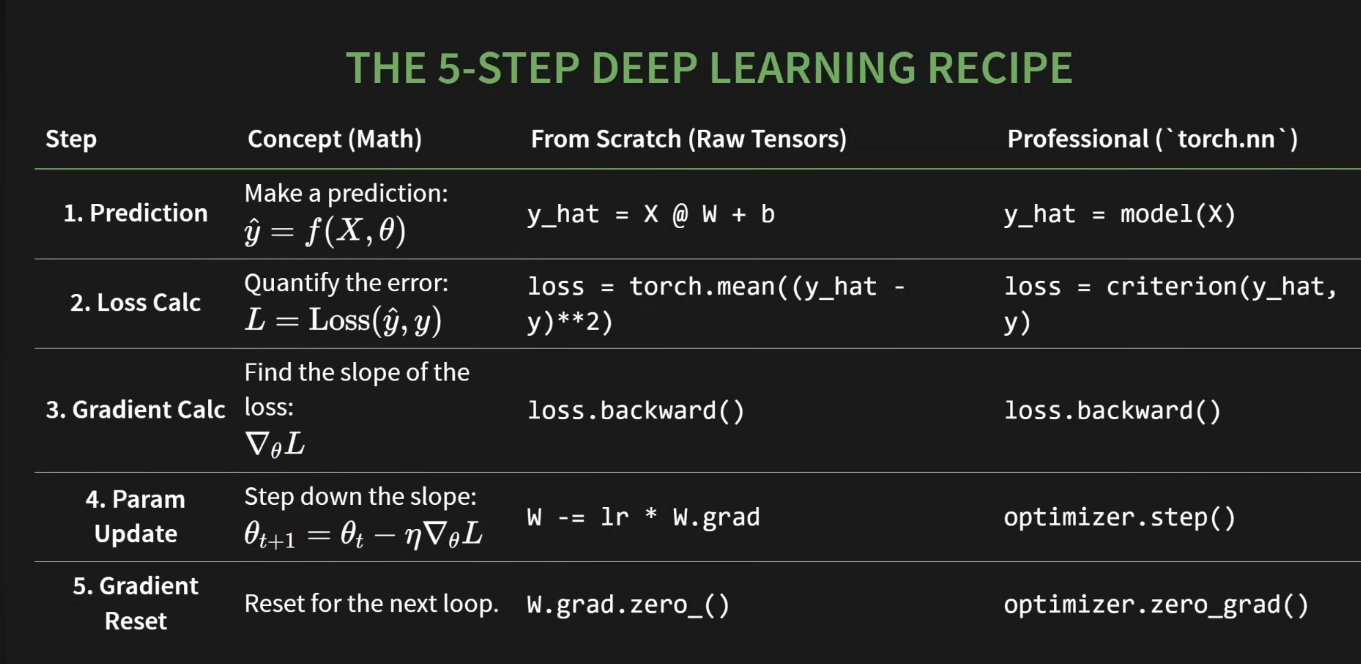

### Pattern 1: Direct Creation from Existing Data — `torch.tensor()`

Use this when you have **actual numbers** (from a Python list, numpy array, or hardcoded values).

```
torch.tensor(data)  →  copies data, infers dtype automatically
```

> **When you'll use it:** Creating ground truth labels, test inputs, or any time you have a known dataset in Python memory.

In [ ]:
import torch

# torch.tensor() takes any Python nested list and converts it to a Tensor.
# dtype is inferred: integers become torch.int64, floats become torch.float32
data = [[1, 2, 3], [4, 5, 6]]
my_tensor = torch.tensor(data)

print(f"Tensor:\n{my_tensor}")
print(f"Shape: {my_tensor.shape}")   # torch.Size([2, 3]) → 2 rows, 3 columns
print(f"Dtype: {my_tensor.dtype}")   # torch.int64 (integers → int64 by default)

# ---
# INTERVIEW NOTE: torch.tensor() vs torch.Tensor()
# torch.tensor(data)  → COPIES data, infers dtype (ALWAYS use this)
# torch.Tensor(shape) → Uninitialized memory, always float32 (avoid, use torch.empty instead)
# ---

tensor([[1, 2, 3],
        [4, 5, 6]])

### Pattern 2: Creation from a Desired Shape

Use this when you know the **dimensions** you need but not the exact values. This is how model weights are initialized.

| Function | What it does | When to use |
|:---|:---|:---|
| `torch.zeros(shape)` | All zeros | Initial bias values, zero masks |
| `torch.ones(shape)` | All ones | Testing, scaling |
| `torch.randn(shape)` | Random from N(0,1) | **Weight initialization** (most common) |
| `torch.empty(shape)` | Uninitialized memory | When you'll fill it immediately |
| `torch.arange(n)` | `[0, 1, 2, ..., n-1]` | Position indices, token IDs |

> **Key insight:** `torch.randn` for weight initialization is standard. Starting with random values instead of zeros breaks symmetry — if all weights are 0, all neurons learn the same thing!

In [ ]:
shape = (3, 4)  # 3 rows, 4 columns

ones   = torch.ones(shape)
zeros  = torch.zeros(shape)
random = torch.randn(shape)   # Values drawn from standard normal: mean=0, std=1
seq    = torch.arange(12).reshape(3, 4)  # [0..11] reshaped to (3,4)

print(f"Ones:\n{ones}\n")
print(f"Zeros:\n{zeros}\n")
print(f"Random (N(0,1)):\n{random}\n")
print(f"Sequential:\n{seq}\n")

# Notice: randn produces float32, while arange produces int64
print(f"randn dtype: {random.dtype}")  # torch.float32
print(f"arange dtype: {seq.dtype}")    # torch.int64

Random: tensor([[-0.2456,  0.9648, -1.1540,  1.1302],
        [ 0.1924, -2.0638,  0.4315,  0.1555],
        [-0.2554, -0.1543,  0.2156, -1.3768]])


### Pattern 3: Creation by Mimicking Another Tensor — `_like` Functions

Use when you need a new tensor with the **same shape, dtype, and device** as an existing one.

This is incredibly useful during inference when you want to create masks or padding tensors that exactly match your data tensors — without having to manually track shape/device.

```python
# Instead of this (error-prone, must track device manually):
mask = torch.zeros(x.shape[0], x.shape[1], device=x.device, dtype=x.dtype)

# Just do this (inherits everything automatically):
mask = torch.zeros_like(x)
```

> **Most common in practice:** `torch.zeros_like(x)` for creating attention masks in Transformers.

In [ ]:
# The template tensor — think of this as "data you already have"
template = torch.tensor([[1, 2], [3, 4]])   # shape=(2,2), dtype=int64

# Create new tensors that MATCH the template's shape + dtype
ones_like = torch.ones_like(template)          # same shape AND dtype (int64)
zeros_like = torch.zeros_like(template)        # same shape AND dtype (int64)

# You CAN override dtype if needed (e.g., you need float for gradient operations)
rand_like = torch.randn_like(template, dtype=torch.float32)

print(f"Template:\n{template}\n")
print(f"ones_like (inherits int64):\n{ones_like}\n")
print(f"rand_like (dtype overridden to float32):\n{rand_like}\n")

# PRACTICAL USE: Creating a padding mask that matches a batch of token IDs
token_ids = torch.randint(0, 1000, (2, 10))  # batch of 2 sentences, length 10
padding_mask = torch.zeros_like(token_ids)   # same (2,10) shape, no hardcoding
print(f"Padding mask shape matches token_ids: {padding_mask.shape == token_ids.shape}")

Randn_like Tensor:
 tensor([[ 1.7654, -0.5371],
        [ 0.0589,  0.8725]])


### What's Inside a Tensor? The Three Debug Attributes: `.shape`, `.dtype`, `.device`

These three attributes are the first thing you check when debugging a shape mismatch (which is the #1 error in PyTorch):

| Attribute | What it tells you | Common gotcha |
|:---|:---|:---|
| `.shape` | Dimensions like `torch.Size([32, 512])` | Forgetting to add batch dim — `(512,)` != `(1, 512)` |
| `.dtype` | `torch.float32`, `torch.int64`, etc. | Mixing float/int causes runtime errors |
| `.device` | `cpu` or `cuda:0` | Tensors on different devices can't interact |

> **Pro tip:** When you get a shapes error, add `print(tensor.shape)` before and after each operation to find where it breaks. This alone solves 80% of PyTorch debugging.

**Device management pattern used in every real project:**
```python
device = 'cuda' if torch.cuda.is_available() else 'cpu'
x = x.to(device)       # move tensor to device
model = model.to(device)  # move all model params to device
```

In [ ]:
# Create a test tensor — this simulates a batch of 2 data points with 3 features each
tensor = torch.randn(2, 3)

# The three debug attributes you'll use constantly
print(f"Shape:  {tensor.shape}")   # → torch.Size([2, 3])   = 2 rows, 3 cols
print(f"Dtype:  {tensor.dtype}")   # → torch.float32        = decimal numbers
print(f"Device: {tensor.device}")  # → cpu                  = stored in RAM (not GPU)

print(f"\nFull tensor:\n{tensor}")

# ---
# Shape cheatsheet for common AI tasks:
# (batch_size, features)           →  tabular data, embeddings
# (batch_size, seq_len, embed_dim) →  text/sequence data (Transformer input)
# (batch_size, channels, H, W)     →  image data (CNN input)
# ---

# How to check and move to GPU (standard pattern):
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"\nUsing device: {device}")
tensor_on_device = tensor.to(device)
print(f"Device after .to(): {tensor_on_device.device}")

Shape of tensor: torch.Size([2, 3])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


### ⚠️ Critical: Why `float32`? — The `dtype` Rule You Must Know

**Rule:** Model parameters MUST be floats. Input data can be integers (like token IDs).

**Why?** Gradient descent updates parameters by tiny amounts like `-0.00012`. You literally **cannot store** `-0.00012` in an integer type. The math would silently break.

```python
# This is WRONG — you can't learn with integer parameters
W = torch.tensor([[1, 2]], dtype=torch.int64)  # ❌ gradients won't work

# This is CORRECT — float32 for all learnable parameters
W = torch.tensor([[1.0, 2.0]])  # ✅ defaults to float32, ready for gradient descent
```

**The full dtype cheatsheet:**
| dtype | Use case | Size |
|:---|:---|:---|
| `torch.float32` (default) | Model weights, activations, loss | 4 bytes |
| `torch.float16` / `bfloat16` | Mixed-precision training (saves GPU memory) | 2 bytes |
| `torch.int64` | Token IDs, labels, indices | 8 bytes |
| `torch.bool` | Attention masks, padding masks | 1 byte |

> **Interview question:** *"Why do LLMs use bfloat16 instead of float32 during training?"*
> **Answer:** A 7B parameter model needs 7B × 4 bytes = **28GB** in float32. With bfloat16 it's 14GB — fits on two GPUs instead of four. Mixed-precision training uses float16/bfloat16 for forward pass (speed) and float32 for gradient accumulation (precision).

---
## 🎯 Part 1 Interview Cheatsheet — Tensors

**Q: What's the difference between `torch.tensor()` and `torch.Tensor()`?**
- `torch.tensor(data)` — copies data, infers dtype ✅ (always use this)
- `torch.Tensor(3, 4)` — creates uninitialized float32 tensor (use `torch.empty` instead)

**Q: How do you check if a tensor is on GPU?**
```python
tensor.device      # → device(type='cpu') or device(type='cuda', index=0)
tensor.is_cuda     # → True or False
```

**Q: What does `.item()` do?**
```python
loss.item()   # Converts a single-element tensor → plain Python float (crucial for logging)
```

**Q: What's the difference between `.view()` and `.reshape()`?**
- `.view()` — only works on contiguous memory, zero-copy (use when performance matters)
- `.reshape()` — always works, may copy if needed (use as default)

**Q: How do you convert a tensor to numpy?**
```python
arr = tensor.detach().cpu().numpy()
# detach() removes from grad tracking, .cpu() moves to RAM
```

**Common gotchas:**
- `tensor[0]` on shape `(1, 10)` → shape becomes `(10,)` (dimension dropped). Use `tensor[:1]` to keep it as `(1, 10)`
- `(a == b)` on tensors returns a **tensor**, not a bool — use `torch.equal(a, b)` for a bool
- Forgetting `.item()` when logging loss → full computation graph stays in memory → OOM on long runs
---

## Part 2: The Engine of Autograd — `requires_grad`

**Autograd = Automatic Differentiation.** It's PyTorch's built-in gradient calculator.

**Analogy:** If a tensor is the "noun", Autograd is the **nervous system** — it connects all operations so that when you ask "how much did this parameter affect the loss?", PyTorch already has the answer recorded.

**How it works — two phases:**
1. **Forward pass:** PyTorch builds a **computation graph** as operations execute. Every node stores what operation created it.
2. **Backward pass (`loss.backward()`):** PyTorch traverses the graph in reverse using the **chain rule**, computing `∂loss/∂parameter` for every parameter.

**The one switch that activates this:** `requires_grad=True`

```python
# Static data — we NEVER need gradients w.r.t. input data
x = torch.tensor([1.0, 2.0, 3.0])              # requires_grad=False (default)

# Learnable parameter — we ALWAYS need gradients to update it
W = torch.tensor([0.5, 0.5], requires_grad=True)  # autograd now TRACKS W
```

> **Key rule:** Set `requires_grad=True` ONLY on parameters the model will LEARN. Not on input data. Not on labels. Just the weights and biases.

In [ ]:
import torch

# Input data — static, we don't learn from it, so NO gradient tracking
x_data = torch.tensor([[1., 2.], [3., 4.]])
print(f"Input data requires_grad: {x_data.requires_grad}")  # False — not tracked

# Learnable parameter — requires_grad=True tells Autograd: "watch this!"
# Every operation on 'w' will be recorded in the computation graph
w = torch.tensor([[1.0], [2.0]], requires_grad=True)
print(f"Weight parameter requires_grad: {w.requires_grad}")  # True — tracked

# ---
# SHORTCUT: An easier way to mark an existing tensor as a parameter
# w = torch.randn(2, 1)       # not tracked yet
# w.requires_grad_(True)      # mark it in-place (the trailing _ means in-place)
# ---

Data tensor requires_grad: False

Parameter tensor requires_grad: True


In [ ]:
# Three leaf tensors (parameters we want to learn)
a = torch.tensor(2.0, requires_grad=True)  # leaf node — created by user
b = torch.tensor(3.0, requires_grad=True)  # leaf node — created by user
x = torch.tensor(4.0, requires_grad=True)  # leaf node — created by user

# PyTorch silently builds a computation graph as we compute:

# Step 1: y = a + b
# Graph: a → [Add] ← b → y
y = a + b

# Step 2: z = x * y
# Graph: x → [Multiply] ← y → z
z = x * y  # z = 4 * (2+3) = 20

print(f"y = a + b = {y}")  # 5.0
print(f"z = x * y = {z}")  # 20.0

# The graph now records: z was made by multiplying x and y, y was made by adding a and b
# When we call z.backward(), it will use this graph to find dz/da, dz/db, dz/dx
# using the chain rule: dz/da = dz/dy * dy/da = x * 1 = 4

Result of a + b: 5.0
Result of x * y: 20.0


In [ ]:
# .grad_fn is the "breadcrumb" — it proves the computation graph exists
# Each intermediate tensor records WHAT OPERATION created it

print(f"grad_fn for z (came from multiply): {z.grad_fn}")  # MulBackward0
print(f"grad_fn for y (came from add):      {y.grad_fn}")  # AddBackward0
print(f"grad_fn for a (created by user):    {a.grad_fn}")  # None — it's a leaf

# Now let's ask: what are the gradients?
# Mathematically:
# z = x * y, y = a + b
# dz/da = dz/dy * dy/da = x * 1 = 4
# dz/db = dz/dy * dy/db = x * 1 = 4
# dz/dx = y = 5

z.backward()  # traverse graph backwards, compute all gradients

print(f"\nAfter z.backward():")
print(f"dz/da = {a.grad}")  # 4.0  (= x = 4)
print(f"dz/db = {b.grad}")  # 4.0  (= x = 4)
print(f"dz/dx = {x.grad}")  # 5.0  (= y = a+b = 5)

# Verify dz/da: if we increase 'a' by tiny ε, z increases by 4ε → gradient is 4 ✓

grad_fn for z: <MulBackward0 object at 0x7b2071e28b80>
grad_fn for y: <AddBackward0 object at 0x7b2071e28a60>
grad_fn for a: None


### The Computation Graph — Visualized

```
Leaf Tensors          Graph              Gradient flows backward
(requires_grad=True)  (forward pass)     (backward pass ← chain rule)

   a=2.0  ──────┐
                ├──► [Add] ──► y=5.0 ──┐
   b=3.0  ──────┘    (+)               ├──► [Multiply] ──► z=20.0
                                        │    (*)
   x=4.0  ─────────────────────────────┘

After z.backward():
  a.grad = 4.0  (dz/da = x = 4)
  b.grad = 4.0  (dz/db = x = 4)
  x.grad = 5.0  (dz/dx = y = 5)
```

**Why does this matter for neural networks?**

In a real network, `z` is the `loss`. `a`, `b`, `x` are the `W` and `b` parameters. After `loss.backward()`, each parameter's `.grad` tells us: *"If I increase this parameter slightly, the loss increases by this much."* We then move in the **opposite** direction to reduce the loss.

---
## 🎯 Part 2 Interview Cheatsheet — Autograd

**Q: What is `requires_grad=True` doing?**
- It tells PyTorch to record all operations on this tensor in a computation graph so that gradients can be computed during `backward()`.

**Q: What happens if you call `loss.backward()` twice?**
- Error! The computation graph is freed after the first `backward()` call (to save memory).
- To keep the graph: `loss.backward(retain_graph=True)` — but you rarely need this.

**Q: How do you stop PyTorch from tracking gradients temporarily?**
```python
with torch.no_grad():
    y = model(x)  # No graph is built, faster, less memory
# Common uses: inference, validation loop, manual weight updates
```

**Q: What's `detach()`?**
```python
y = x.detach()  # Creates a new tensor sharing data but NOT in the graph
# Use when you want the VALUE but don't want gradients to flow through
```

**Q: What are "leaf tensors"?**
- Tensors created directly by the user (not as result of an operation) with `requires_grad=True`. These are your model's parameters. Only leaf tensors accumulate gradients in `.grad`.
---

## Part 3: Basic Mathematical & Reduction Operations

We have our tensors (nouns) and Autograd (the nervous system). Now we need **operations** (the verbs).

**The two you MUST know cold for interviews:**
1. `*` — element-wise multiplication (Hadamard product)
2. `@` — matrix multiplication (the core of every Linear layer)

**Plus reductions:** `sum()`, `mean()`, `max()`, `min()` — with the critical `dim` argument.

In [ ]:
import torch

# ============================================================
# ELEMENT-WISE MULTIPLICATION (Hadamard product): a * b
# Rules: Both tensors must have the SAME SHAPE (or be broadcastable)
# Use cases: Applying a mask, gating mechanisms (attention gates, LSTM gates)
# ============================================================

a = torch.tensor([[1, 2], [3, 4]])    # shape (2,2)
b = torch.tensor([[10, 20], [30, 40]]) # shape (2,2)

# Each element multiplied with its counterpart:
# [[1*10, 2*20], [3*30, 4*40]]
element_wise = a * b  # equivalent to torch.mul(a, b)

print(f"a:\n{a}\n")
print(f"b:\n{b}\n")
print(f"Element-wise (a * b):\n{element_wise}\n")
# Shape stays (2,2) — same as inputs

# REAL WORLD USE: Applying an attention mask
# mask = torch.tensor([[1, 1, 0]])  # 1=attend, 0=ignore
# masked_values = scores * mask     # zeros out ignored positions

Tensor a:
 tensor([[1, 2],
        [3, 4]])

Tensor b:
 tensor([[10, 20],
        [30, 40]])

Element-wise Product (a * b):
 tensor([[ 10,  40],
        [ 90, 160]])


In [ ]:
# ============================================================
# MATRIX MULTIPLICATION: m1 @ m2
# Rules: cols of m1 must equal rows of m2
#        (m, n) @ (n, p) → (m, p)
# This IS the core operation of nn.Linear!
# nn.Linear literally does: output = input @ weight.T + bias
# ============================================================

m1 = torch.tensor([[1, 2, 3],   # shape: (2, 3)  — 2 rows, 3 cols
                   [4, 5, 6]])
m2 = torch.tensor([[7, 8],      # shape: (3, 2)  — 3 rows, 2 cols
                   [9, 10],
                   [11, 12]])

# (2, 3) @ (3, 2) → (2, 2)
# First element: row0 · col0 = (1*7) + (2*9) + (3*11) = 7 + 18 + 33 = 58
result = m1 @ m2  # equivalent to torch.matmul(m1, m2)

print(f"m1 shape: {m1.shape}")     # (2, 3)
print(f"m2 shape: {m2.shape}")     # (3, 2)
print(f"result shape: {result.shape}")  # (2, 2) — rules: (2,3)@(3,2)=(2,2)
print(f"\nMatrix product:\n{result}")

# MEMORY AID: Think of m1 rows as "data points" and m2 cols as "output features"
# 2 data points × 3 input features → 2 data points × 2 output features

# INTERVIEW TIP: What's the difference between @ and torch.bmm()?
# @  = torch.matmul() supports broadcasting for batches: (B,m,n)@(B,n,p)→(B,m,p)
# torch.bmm() = strictly 3D batched: (B,m,n)@(B,n,p)→(B,m,p), no broadcasting

Matrix 1 (shape torch.Size([2, 3])):
 tensor([[1, 2, 3],
        [4, 5, 6]])

Matrix 2 (shape torch.Size([3, 2])):
 tensor([[ 7,  8],
        [ 9, 10],
        [11, 12]])

Matrix Product (m1 @ m2):
 tensor([[ 58,  64],
        [139, 154]])


### 3.2. Reduction Operations — Aggregating Across a Tensor

A **reduction** collapses some or all dimensions of a tensor into a single number (or smaller tensor). The most common: `sum()`, `mean()`, `max()`, `min()`.

**Without `dim`:** reduces the entire tensor to a scalar.
**With `dim`:** reduces along ONE specific axis, keeping all others.

> **When you'll use it:**
> - `loss = errors.mean()` — MSE loss averages all squared errors
> - `probs = logits.softmax(dim=-1)` — normalize across class scores
> - `pooled = activations.mean(dim=1)` — global average pooling in CNNs/Transformers

In [ ]:
scores = torch.tensor([[10., 20., 30.],  # Student 1: [Assignment1, Assignment2, Assignment3]
                       [ 5., 10., 15.]]) # Student 2: [Assignment1, Assignment2, Assignment3]

# No dim argument → reduce EVERYTHING to a single number
total_sum = scores.sum()     # 10+20+30+5+10+15 = 90
average   = scores.mean()    # 90 / 6 = 15
max_val   = scores.max()     # 30
min_val   = scores.min()     # 5

print(f"Scores:\n{scores}\n")
print(f"Total sum (all elements): {total_sum}")  # scalar
print(f"Overall mean:             {average}")    # scalar
print(f"Max value:                {max_val}")    # scalar
print(f"Min value:                {min_val}")    # scalar

Scores Tensor:
 tensor([[10., 20., 30.],
        [ 5., 10., 15.]])

Total Sum: 90.0
Overall Mean: 15.0


### 3.3. The `dim` Argument — The Most Important Detail ⭐

The `dim` argument tells the function **which axis to collapse/reduce along**.

**Mental model for 2D tensors:**

```
shape = (rows, cols) = (dim=0, dim=1)

dim=0 → collapse ROWS, operate vertically   ↕  result has 1 row, all cols remain
dim=1 → collapse COLS, operate horizontally ↔  result has all rows, 1 col
```

**Example with our (2,3) scores tensor:**
```
              Col0  Col1  Col2   ← sum(dim=1) →
Student1:     10    20    30          60
Student2:      5    10    15          30
                ↓    ↓    ↓
sum(dim=0):   15    30    45
```

> **Interview tip:** "The dimension you specify is the one that **disappears** from the output shape."
> - `(2, 3).sum(dim=0)` → `(3,)` — the dim=0 axis (size 2) disappeared
> - `(2, 3).sum(dim=1)` → `(2,)` — the dim=1 axis (size 3) disappeared
> - `(2, 3).sum(dim=1, keepdim=True)` → `(2, 1)` — keepdim=True preserves the axis

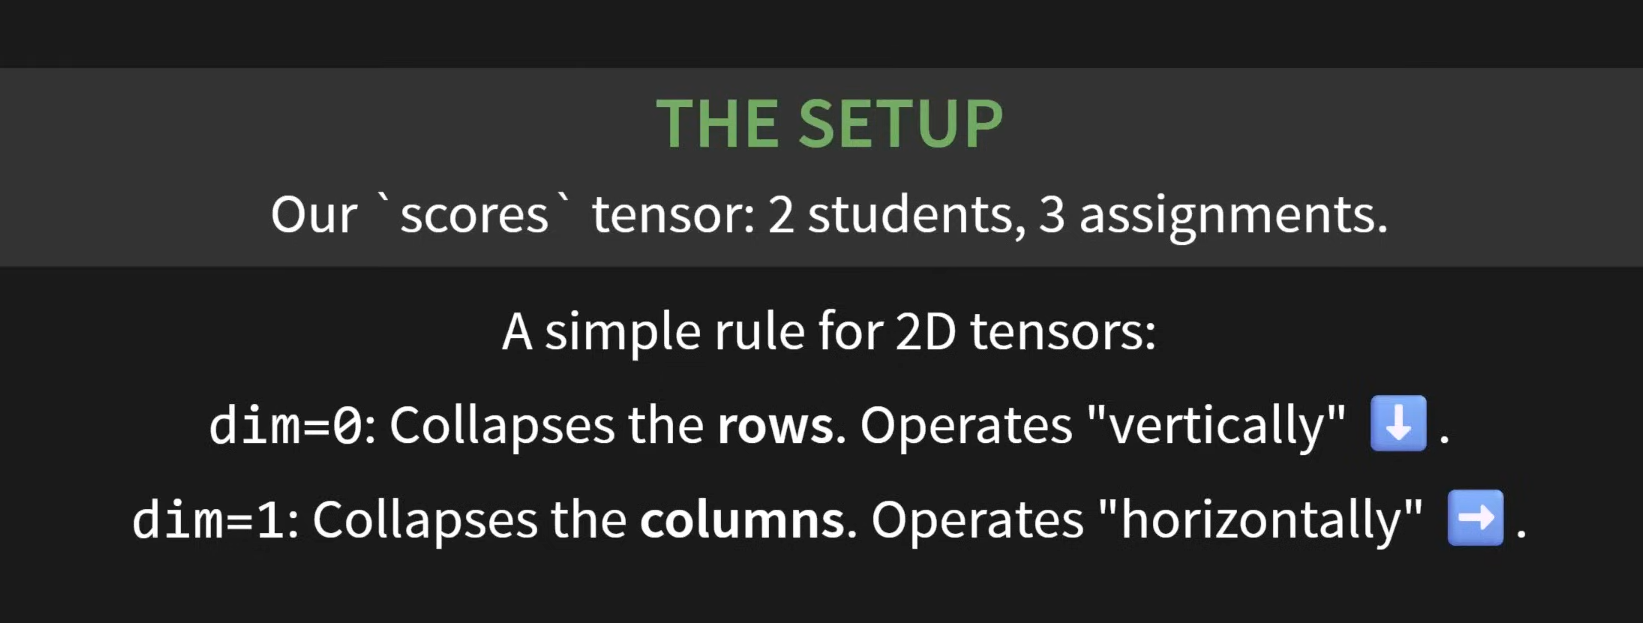

In [ ]:
scores = torch.tensor([[10., 20., 30.],  # Student 1
                       [ 5., 10., 15.]]) # Student 2

# dim=0: collapse the ROWS dimension (operate vertically ↕)
# "For each COLUMN, what's the sum across all students?"
# (2, 3) → sum(dim=0) → (3,)  [the '2' rows dimension disappears]
sum_per_assignment = scores.sum(dim=0)  # [10+5, 20+10, 30+15] = [15, 30, 45]

# dim=1: collapse the COLUMNS dimension (operate horizontally ↔)
# "For each STUDENT, what's their total score across all assignments?"
# (2, 3) → sum(dim=1) → (2,)  [the '3' cols dimension disappears]
sum_per_student = scores.sum(dim=1)     # [10+20+30, 5+10+15] = [60, 30]

print(f"Original scores shape: {scores.shape}\n")

print(f"sum(dim=0) → shape {sum_per_assignment.shape}")
print(f"  Per assignment: {sum_per_assignment}\n")

print(f"sum(dim=1) → shape {sum_per_student.shape}")
print(f"  Per student: {sum_per_student}\n")

# keepdim=True → preserves the collapsed axis as size 1 (useful for broadcasting)
sum_keepdim = scores.sum(dim=1, keepdim=True)
print(f"sum(dim=1, keepdim=True) → shape {sum_keepdim.shape}")  # (2, 1) not (2,)
print(f"  {sum_keepdim}")

Original Scores:
 tensor([[10., 20., 30.],
        [ 5., 10., 15.]])

Sum per assignment (dim=0): tensor([15., 30., 45.])
Sum per student (dim=1):    tensor([60., 30.])


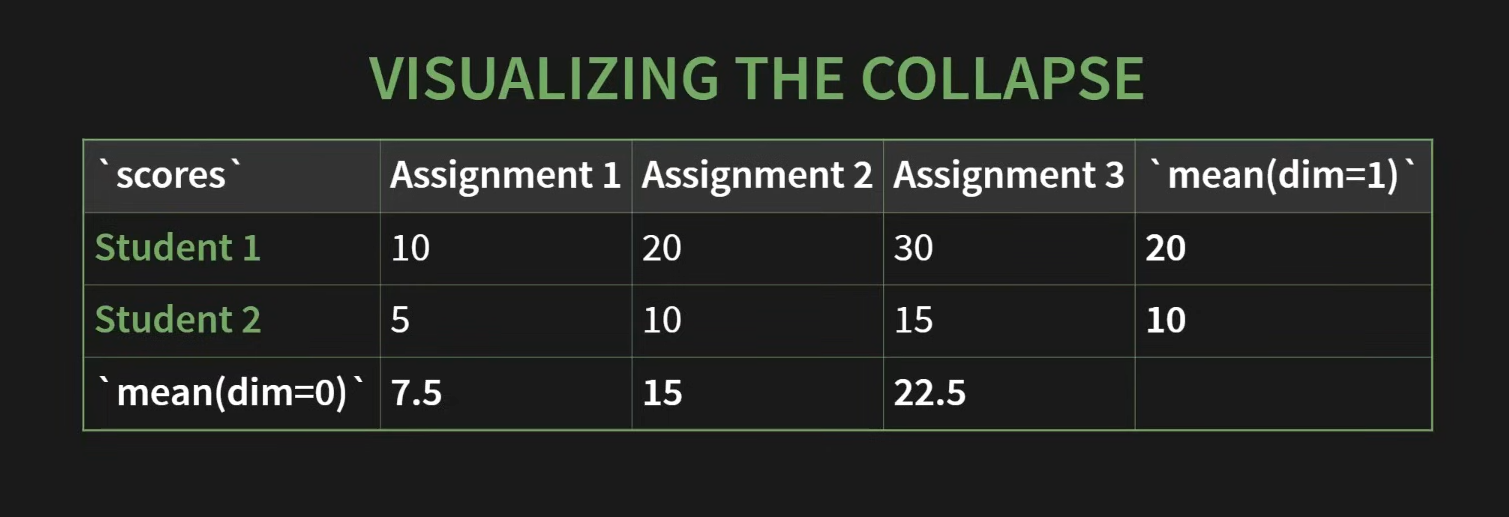

In [ ]:
# Same logic for mean() — the pattern is identical across all reductions
mean_per_assignment = scores.mean(dim=0)  # average score per assignment
mean_per_student    = scores.mean(dim=1)  # average score per student

print(f"Mean per assignment (dim=0): {mean_per_assignment}")
print(f"Mean per student    (dim=1): {mean_per_student}")

# ---
# INTERVIEW BONUS: Common patterns you'll see in production code
# ---

# 1. Softmax — normalize logits to probabilities (ALWAYS use dim=-1 in practice)
logits = torch.tensor([[2.0, 1.0, 0.5]])
probs = torch.softmax(logits, dim=-1)   # dim=-1 = last dim (safer than dim=1)
print(f"\nLogits: {logits}")
print(f"Softmax: {probs}")
print(f"Sum of probs: {probs.sum()}")   # Always 1.0

# 2. Global average pooling (used in CNNs, Transformers before final classifier)
# If activations = (batch, seq_len, embed_dim), pool the sequence
batch_size, seq_len, embed_dim = 2, 5, 8
activations = torch.randn(batch_size, seq_len, embed_dim)
pooled = activations.mean(dim=1)  # (2, 5, 8) → (2, 8): average across sequence
print(f"\nActivations shape: {activations.shape} → Pooled shape: {pooled.shape}")

Original Scores:
 tensor([[10., 20., 30.],
        [ 5., 10., 15.]])

Mean per assignment (dim=0): tensor([ 7.5000, 15.0000, 22.5000])
Mean per student (dim=1):    tensor([20., 10.])


## Part 4: Advanced Indexing & Selection Primitives

If operations are the "verbs", indexing lets you say **which data to act on** with precision.

We'll cover three kinds of selection, increasing in power:
1. **Standard indexing** — uniform block selection (`x[1]`, `x[:, 2]`)
2. **`argmax` / `topk`** — finding the best predictions
3. **`torch.gather()`** — per-row dynamic lookup (**critical for NLP: extracting the loss for each token's correct answer**)

> **Why `gather()` matters in LLMs:** During training, given a sequence of 512 tokens, you predict probabilities for each position, then use `gather()` to extract ONLY the probability the model assigned to the CORRECT next token. That's how cross-entropy loss works for language models.

### 4.1. Standard Indexing — Same as NumPy / Python Lists

```python
x[row_idx]          # select a row
x[:, col_idx]       # select a column (: means "all rows")
x[row_idx, col_idx] # select a single element
x[2:5]              # slice (rows 2 through 4)
x[start:end:step]   # full slice syntax
```

In [ ]:
import torch

x = torch.tensor([[0,  1,  2,  3 ],   # row 0
                  [4,  5,  6,  7 ],   # row 1
                  [8,  9,  10, 11]])  # row 2

# Basic row/col selection
row_1  = x[1]      # row at index 1: [4, 5, 6, 7]
col_2  = x[:, 2]   # column at index 2: [2, 6, 10]   (':' = all rows)
elem   = x[1, 3]   # row=1, col=3: element 7

print(f"Row 1:      {row_1}")   # shape (4,)
print(f"Column 2:   {col_2}")   # shape (3,)
print(f"x[1,3]:     {elem}")    # scalar

# Slicing — selects a sub-tensor (no copy, returns a VIEW)
block = x[0:2, 1:3]   # rows 0-1, cols 1-2
print(f"\nBlock x[0:2, 1:3]:\n{block}")

# CRITICAL INTERVIEW POINT: Slices return VIEWS, not copies
# Modifying the view modifies the original!
view = x[0]
view[0] = 999
print(f"\nAfter modifying view[0], x[0] = {x[0]}")  # x[0][0] also changed!
# To avoid this, use .clone(): x[0].clone() to get an independent copy

Row 1: tensor([4, 5, 6, 7])

Column 2: tensor([ 2,  6, 10])

Element at (1, 3): 7


### 4.2 Finding Best Predictions — `argmax` and `topk`

After a model produces scores/logits, you need to find which class it chose.

| Function | Returns | Use case |
|:---|:---|:---|
| `torch.argmax(x, dim)` | Index of max value | Greedy decoding, accuracy check |
| `torch.topk(x, k, dim)` | Top-k *values* AND *indices* | Beam search, top-k sampling in LLMs |
| `torch.max(x, dim)` | Max *values* AND *argmax* | When you need both value and index |

> **In LLM generation:** greedy decoding = `next_token = logits.argmax(dim=-1)`. Top-k sampling = `topk_logits, topk_indices = torch.topk(logits, k=50, dim=-1)`

In [ ]:
import torch

# Imagine a classifier predicting which of 5 classes each item belongs to
# Each row = one data point, each column = score for that class
scores = torch.tensor([
    [10, 20,  0,  5,  6],  # Item 0: highest score is class 1 (value 20)
    [ 2,  3,  5,  6,  8]   # Item 1: highest score is class 4 (value 8)
])

# argmax(dim=1): "for each item (row), which class has the highest score?"
# → this is how you compute accuracy: compare predicted class to true label
predicted_classes = torch.argmax(scores, dim=1)
print(f"Predicted class per item: {predicted_classes}")  # [1, 4]

# argmax(dim=0): "for each class (column), which item scored it highest?"
best_item_per_class = torch.argmax(scores, dim=0)
print(f"Best item per class: {best_item_per_class}")  # varies

# topk: returns BOTH the values and their indices — useful for sampling
top3_values, top3_indices = torch.topk(scores, k=3, dim=1)
print(f"\nTop-3 class scores:\n{top3_values}")
print(f"Top-3 class indices:\n{top3_indices}")

# COMPUTING ACCURACY — the real-world usage
true_labels = torch.tensor([1, 4])  # true class for each item
accuracy = (predicted_classes == true_labels).float().mean()
print(f"\nAccuracy: {accuracy.item():.0%}")  # 100% (both predictions correct)

tensor([1, 4])
tensor([0, 0, 1, 1, 1])


### 4.3 Per-Row Dynamic Lookups — `torch.gather()` ⭐ (Advanced + Interview Favorite)

**The problem:** Standard indexing is *uniform* — "get column 2 for ALL rows".

But what if you need a **different** column for each row?

```
From row 0: get element at column 2
From row 1: get element at column 0
From row 2: get element at column 3
```

Standard indexing can't do this efficiently. `torch.gather()` is built exactly for this.

**Signature:** `torch.gather(input, dim, index)`
- `dim=1` → we're selecting along the column axis (each row gets its own column index)

**Why this matters in LLMs:**
```
# After the model outputs probabilities for ALL 50,000 vocab tokens at each position...
# We only need the probability it assigned to the CORRECT next token
# labels = [42, 7809, 231, ...]    ← the correct token at each position
# probs = (seq_len, vocab_size)    ← model's output

correct_probs = torch.gather(probs, dim=1, index=labels.unsqueeze(1))
# This is essentially what CrossEntropyLoss does internally
```

In [ ]:
import torch

# Picture this as a vocabulary lookup table or a reward table:
# 3 data points, each has scores/values at 4 possible positions (cols 0-3)
data = torch.tensor([
    [10, 11, 12, 13],   # row 0: values at positions 0,1,2,3
    [20, 21, 22, 23],   # row 1: values at positions 0,1,2,3
    [30, 31, 32, 33]    # row 2: values at positions 0,1,2,3
])

# Our "personalized lookup": for each row, WHICH column to pick?
# row 0 → pick column 2 (value = 12)
# row 1 → pick column 0 (value = 20)
# row 2 → pick column 3 (value = 33)
indices = torch.tensor([[2],   # for row 0, grab column 2
                        [0],   # for row 1, grab column 0
                        [3]])  # for row 2, grab column 3

# gather(data, dim=1, index) — "for each row, grab the element at the given col"
result = torch.gather(data, dim=1, index=indices)

print(f"Data:\n{data}\n")
print(f"Indices to pick:\n{indices}\n")
print(f"Gathered values:\n{result}")
# Expected: [[12], [20], [33]]

# ---
# LLM USE CASE — picking the correct token probability:
# ---
vocab_size = 5
seq_len = 3
# Model output: probability distribution over vocabulary at each position
log_probs = torch.log_softmax(torch.randn(seq_len, vocab_size), dim=-1)

# The correct next token at each position
correct_tokens = torch.tensor([[2], [4], [1]])  # shape (3, 1)

# Extract the model's assigned probability for the correct token
correct_log_probs = torch.gather(log_probs, dim=1, index=correct_tokens)
print(f"\nLog probs shape: {log_probs.shape}")
print(f"Correct token log probs: {correct_log_probs.squeeze()}")
# NLL loss = -correct_log_probs.mean()  ← this is what CrossEntropyLoss computes!

Selected Values:
 tensor([[12],
        [20],
        [33]])


## Part 5: The Forward Pass — Manually Making a Prediction

We now have all the primitives we need. Time to build something real.

**The Forward Pass** = feeding data through the model to get a prediction. It's **Step 1** of the 5-step training loop.

**Our model:** Simple linear regression — `ŷ = XW + b`

This is not a toy. The **exact same `X @ W + b` operation** is what `nn.Linear` does. The `nn.Linear` layer inside every Transformer is literally this formula, just with bigger matrices.

**Our goal:**
1. Create synthetic data that follows `y = 2x + 1`
2. Initialize random parameters `W` and `b`
3. Make a prediction with `ŷ = XW + b`
4. Notice it's wrong (random params → bad predictions)
5. Then fix it by training in Parts 6 & 7

### 5.1. Why `ŷ = XW + b`? — The Math Behind Every Linear Layer

A **linear layer** maps an input vector of size `D_in` to an output vector of size `D_out`:

```
Input X: shape (N, D_in)   — N data points, each with D_in features
Weight W: shape (D_in, D_out)  — the learnable mapping
Bias b: shape (D_out,)         — a learnable offset
Output ŷ: shape (N, D_out)  — N predictions
```

The matrix multiplication `X @ W` computes a **weighted sum** of input features for each output.
The bias `b` shifts the output.

**In a Transformer:** `D_in = embedding_dim ≈ 4096`, `D_out = vocab_size ≈ 32000`. The final linear layer maps each token's embedding to a score for every word in the vocabulary. Same `X @ W + b`, just much bigger.

In [ ]:
import torch

# ============================================================
# STEP 1: Create synthetic training data
# True relationship: y = 2x + 1 (with small noise)
# We'll see if our model can LEARN this from data
# ============================================================

N     = 100    # number of training data points
D_in  = 1      # each input has 1 feature (one number)
D_out = 1      # each output is 1 number

# Random input data: N data points, each with D_in features
# Shape: (100, 1)
X = torch.randn(N, D_in)

# The "ground truth" — data generated by y = 2x + 1 + small_noise
# We set the TRUE parameters so we can verify our model learns them
true_W = torch.tensor([[2.0]])   # the true weight we want to learn
true_b = torch.tensor([1.0])     # the true bias we want to learn
noise  = torch.randn(N, D_out) * 0.1  # realistic: real data has noise

y_true = X @ true_W + true_b + noise  # shape: (100, 1)

print(f"X shape:      {X.shape}")       # (100, 1)
print(f"y_true shape: {y_true.shape}")  # (100, 1)

# Quick sanity check: the approximate relationship y ≈ 2x + 1
print(f"\nFirst 5 rows of (X, y_true):")
for i in range(5):
    print(f"  x={X[i,0].item():+.3f}  →  y_true={y_true[i,0].item():+.3f}  "
          f"(approx: 2*{X[i,0].item():.2f}+1 = {2*X[i,0].item()+1:.3f})")

Input Data X (first 3 rows):
 tensor([[-0.7765],
        [-0.2831],
        [ 1.4699]])

True Labels y_true (first 3 rows):
 tensor([[-0.4086],
        [ 0.2342],
        [ 3.9386]])


In [ ]:
# ============================================================
# STEP 2: Initialize the model's parameters (the "brain" of the model)
# ============================================================
# W has shape (D_in, D_out) = (1, 1) — a single number
# This must match the matrix multiplication: X(100,1) @ W(1,1) → output(100,1)
W = torch.randn(D_in, D_out, requires_grad=True)  # random initial value
b = torch.randn(1,          requires_grad=True)   # random initial bias

print(f"Initial W: {W.item():.4f}  (true value is 2.0)")
print(f"Initial b: {b.item():.4f}  (true value is 1.0)")
print(f"\nThese are completely random → our predictions will be terrible right now")
print(f"W.requires_grad = {W.requires_grad}")  # True — autograd is watching W
print(f"b.requires_grad = {b.requires_grad}")  # True — autograd is watching b

# ---
# MEMORY TIP: Why requires_grad=True matters here:
# If we forget this, loss.backward() will silently produce None gradients
# and the model will NEVER learn (the most sneaky bug in PyTorch)
# ---

Initial Weight W:
 tensor([[0.7532]], requires_grad=True)

Initial Bias b:
 tensor([0.4161], requires_grad=True)


In [ ]:
# ============================================================
# STEP 3: THE FORWARD PASS — ŷ = X @ W + b
# This single line IS the model. In nn.Linear, this is exactly what happens.
# ============================================================
y_hat = X @ W + b   # matrix multiply input by weight, add bias

print(f"y_hat shape: {y_hat.shape}")   # (100, 1) — same as y_true ✓
print(f"y_hat dtype: {y_hat.dtype}")   # float32 ✓

# Notice the grad_fn — proof that autograd is tracking this
print(f"y_hat.grad_fn: {y_hat.grad_fn}")   # AddBackward0 (last op was + b)

print(f"\n--- First 5 predictions vs ground truth ---")
for i in range(5):
    print(f"  ŷ={y_hat[i,0].item():+.3f}   y_true={y_true[i,0].item():+.3f}   "
          f"error={abs(y_hat[i,0].item() - y_true[i,0].item()):.3f}")

# As expected, predictions are way off because W and b are random
# In Part 6 we'll measure exactly HOW wrong, and in Part 7 we'll fix it

Shape of our prediction y_hat: torch.Size([10, 1])

Prediction y_hat (first 3 rows):
 tensor([[-0.1688],
        [ 0.2029],
        [ 1.5232]], grad_fn=<SliceBackward0>)

True Labels y_true (first 3 rows):
 tensor([[-0.4086],
        [ 0.2342],
        [ 3.9386]])


## Part 6: The Backward Pass — Calculating Gradients

The forward pass made a prediction. Now we need to:
1. **Measure how wrong we were** → the **loss** (a single number)
2. **Figure out WHICH DIRECTION to adjust each parameter** → the **gradients**

**Analogy:** You're tuning a radio to eliminate static. The forward pass lets you *hear* the static. The loss quantifies *how much* static there is. The backward pass tells you exactly *which direction* to turn each knob (W and b) to reduce it.

**The math we implement:**
- **Loss (MSE):** $L = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2$
- **Backward pass:** `loss.backward()` computes $\frac{\partial L}{\partial W}$ and $\frac{\partial L}{\partial b}$ using the chain rule — automatically, through the computation graph we built in Part 2.

### 6.1. The Loss Function — One Number to Rule Them All

**Mean Squared Error (MSE)** = average of squared prediction errors:
$$L = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2$$

**Why square the error?**
1. Squaring makes all errors positive (negative error is just as bad)
2. Squaring penalizes large errors MORE (a 2× larger error → 4× larger penalty)
3. The smooth curve of MSE makes gradient-based optimization easy

**Interview Q:** *"When would you NOT use MSE?"*
- **Classification:** Use Cross-Entropy Loss (predicting probabilities)
- **Robust regression:** Use MAE (Mean Absolute Error) when outliers should be downweighted
- **Language models:** Use Cross-Entropy over vocab distribution

In [ ]:
# y_hat = X @ W + b  (from the forward pass in Part 5)

# Step 1: compute the error at each data point
error = y_hat - y_true           # shape (100, 1) — positive or negative

# Step 2: square each error (all positive, larger errors penalized more)
squared_error = error ** 2        # shape (100, 1)

# Step 3: take the mean across all data points → single scalar
loss = squared_error.mean()       # shape () — a single number

print(f"Mean error:         {error.mean().item():+.4f}")
print(f"Mean absolute error: {error.abs().mean().item():.4f}")
print(f"MSE Loss:           {loss.item():.4f}  ← this is what we minimize")

# Note: loss also HAS a grad_fn because it's derived from W and b (which require grad)
print(f"\nloss.grad_fn: {loss.grad_fn}")  # MeanBackward0

# ---
# SHORTCUT (what you'll use in production): nn.MSELoss()
# loss_fn = torch.nn.MSELoss()
# loss = loss_fn(y_hat, y_true)   ← same result, cleaner code
# ---

Prediction (first 3):
 tensor([[-0.1688],
        [ 0.2029],
        [ 1.5232]], grad_fn=<SliceBackward0>)

Truth (first 3):
 tensor([[-0.4086],
        [ 0.2342],
        [ 3.9386]])

Loss (a single number): 1.7245867252349854


### 6.2. `loss.backward()` — The Chain Rule, Automated

`loss.backward()` traverses the computation graph **in reverse** and computes the gradient of `loss` w.r.t. every leaf tensor with `requires_grad=True`.

**What it computes for our model:**
- $\frac{\partial L}{\partial W}$ — stored in `W.grad`
- $\frac{\partial L}{\partial b}$ — stored in `b.grad`

For our MSE loss $L = \frac{1}{N}(XW + b - y)^2$:
$$\frac{\partial L}{\partial W} = \frac{2}{N} X^T(XW + b - y)$$
$$\frac{\partial L}{\partial b} = \frac{2}{N}\sum(XW + b - y)$$

**You don't need to compute these manually.** `backward()` handles it for any model, any depth. This is the entire reason PyTorch exists.

> **Interview Q:** *"What would happen if you called `backward()` twice in a row without `retain_graph=True`?"*
> **A:** RuntimeError. The graph is freed after the first call to save memory. You must `loss.backward(retain_graph=True)` if you need to backward through the same graph again (rare).

In [ ]:
# Before calling backward(), the .grad attributes are None
print(f"Before backward(): W.grad = {W.grad}")  # None
print(f"Before backward(): b.grad = {b.grad}")  # None

# THE BACKWARD PASS — one line to compute ALL gradients
loss.backward()

# After backward(), the gradients are populated!
print(f"\nAfter backward():")
print(f"W.grad = {W.grad}")  # ∂L/∂W
print(f"b.grad = {b.grad}")  # ∂L/∂b

# The graph is now freed (to save memory)
# Calling loss.backward() again would raise a RuntimeError

### 6.3. Reading the Gradients — The Direction of Steepest *Ascent*

After `backward()`, each `param.grad` tells you:

> *"If I increase this parameter by a small amount, the loss will change by approximately `grad × amount`."*

**Key insight:** The gradient points toward **steepest increase** in loss. To *decrease* the loss (our goal), we move in the **opposite** direction:

```
W_new = W_old - learning_rate * W.grad   ← subtract (go opposite of gradient)
```

If `W.grad` is **negative** → increasing W *decreases* loss → we should increase W → we subtract a negative number → W increases. The math always works out correctly.

This is why the update rule always has a **minus sign**: `θ -= lr * θ.grad`

In [ ]:
# W.grad and b.grad are now populated with the gradients
print(f"W.grad = {W.grad.item():+.4f}")
print(f"b.grad = {b.grad.item():+.4f}")

print(f"\nIntuition:")
print(f"  W.grad sign tells us: {'increasing W DECREASES loss' if W.grad.item() < 0 else 'increasing W INCREASES loss'}")
print(f"  b.grad sign tells us: {'increasing b DECREASES loss' if b.grad.item() < 0 else 'increasing b INCREASES loss'}")

# To REDUCE the loss, we move OPPOSITE to the gradient:
# W_new = W_old - lr * W.grad
# b_new = b_old - lr * b.grad
lr = 0.01
print(f"\nIf we were to do ONE manual update:")
print(f"  W: {W.item():.4f} → {W.item() - lr * W.grad.item():.4f}  (moving toward 2.0)")
print(f"  b: {b.item():.4f} → {b.item() - lr * b.grad.item():.4f}  (moving toward 1.0)")

Gradient for W (∂L/∂W):
 tensor([[-2.0537]])

Gradient for b (∂L/∂b):
 tensor([-1.5788])


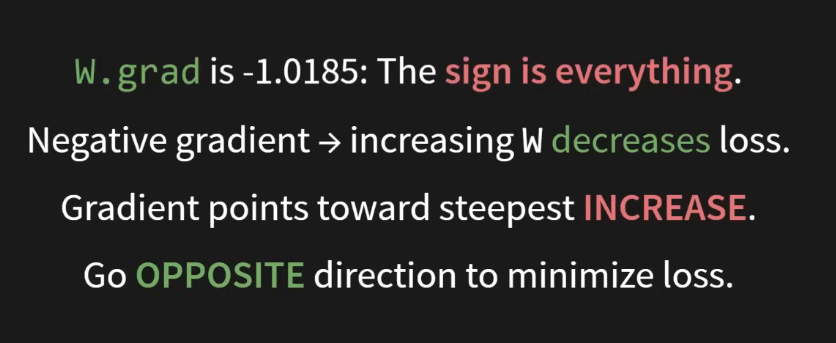

## Part 7: The Training Loop — Gradient Descent From Scratch ⭐

**This is the most important section.** Everything else was building up to this.

**Analogy:** You're on a foggy mountain trying to reach the lowest valley (minimum loss). You can't see the full landscape — but you can feel the slope under your feet (gradients) and take one small step downhill at a time. That's gradient descent.

**The Gradient Descent Update Rule:**
$$\theta_{t+1} = \theta_t - \eta \cdot \nabla_\theta L$$

In our case:
- $\theta$ = our parameters `W` and `b`
- $\eta$ (eta) = **learning rate** — how big a step to take (hyperparameter you choose)
- $\nabla_\theta L$ = the gradient (stored in `W.grad` and `b.grad` after `backward()`)

So the update is:
```
W_new = W_old - learning_rate * W.grad
b_new = b_old - learning_rate * b.grad
```

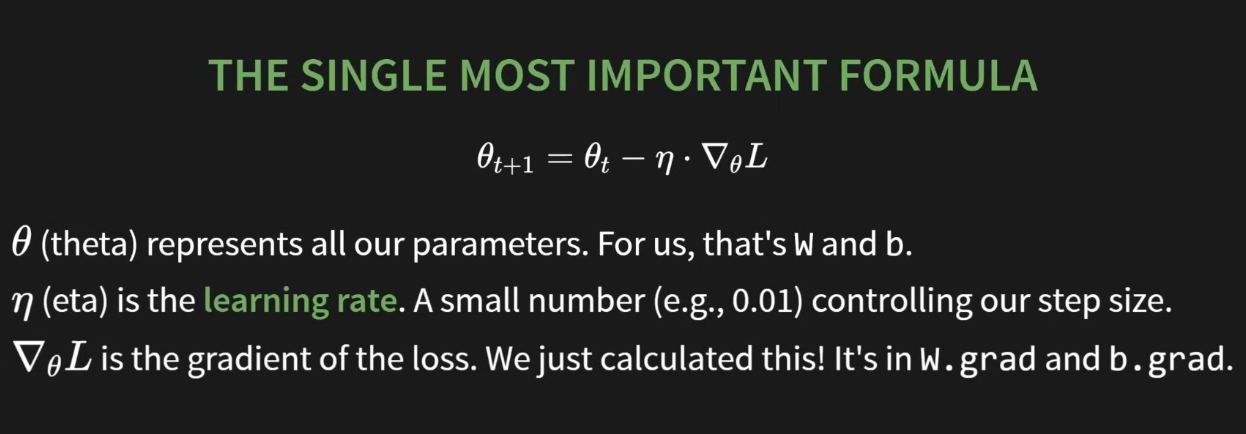

### Why the Minus Sign? — Intuition for the Update Rule

The gradient $\nabla_\theta L$ points in the direction of **steepest INCREASE** in loss. We want to DECREASE the loss. So we go in the **opposite** direction → subtract.

```
W.grad is positive (+)  →  increasing W would increase loss
→ we subtract: W -= lr * (+W.grad) → W decreases → loss decreases ✓

W.grad is negative (-)  →  increasing W would decrease loss
→ we subtract: W -= lr * (-W.grad) → W increases → loss decreases ✓
```

The minus sign automatically handles both cases.

### The Learning Rate `η` — The Most Important Hyperparameter

The learning rate controls **step size**. Getting it right is critical:

| Learning rate | Effect | Symptom |
|:---|:---|:---|
| Too **large** (e.g., 1.0) | Steps overshoot the minimum | Loss oscillates or diverges |
| Too **small** (e.g., 1e-7) | Tiny steps, very slow | Training takes forever |
| **Just right** (e.g., 1e-3, 1e-4) | Converges smoothly | Loss decreases steadily |

**Common defaults** (starting points in practice):
- Adam optimizer: `lr=1e-3` or `lr=3e-4`
- SGD: `lr=0.01` to `0.1`
- LLM fine-tuning: `lr=2e-5` to `5e-5`

> **Tip:** Learning rate schedulers (reduce LR over time, e.g., `CosineAnnealingLR`) are almost always used in production to avoid overshooting at the end of training.

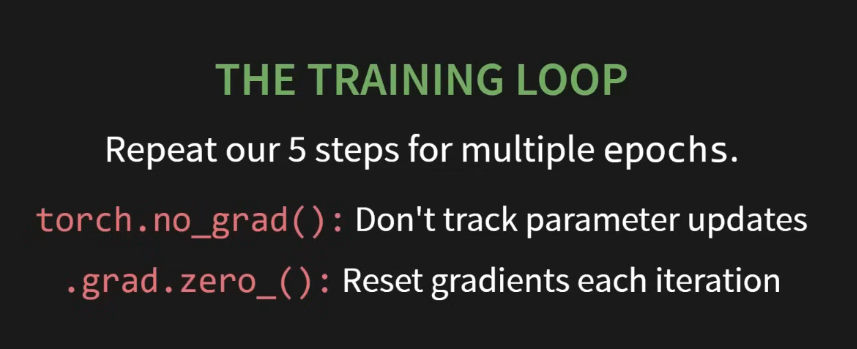

In [ ]:
import torch

# ============================================================
# FULL TRAINING LOOP FROM SCRATCH
# Re-using X and y_true from Part 5
# ============================================================

# Fresh data (in case cells were run out of order)
N, D_in, D_out = 100, 1, 1
X      = torch.randn(N, D_in)
true_W = torch.tensor([[2.0]])
true_b = torch.tensor([1.0])
y_true = X @ true_W + true_b + torch.randn(N, D_out) * 0.1

# Fresh random parameters — the model starts knowing NOTHING
W = torch.randn(D_in, D_out, requires_grad=True)
b = torch.randn(1,          requires_grad=True)

learning_rate = 0.05   # step size for gradient descent
epochs        = 200    # number of times to run through the entire dataset

print(f"Starting: W={W.item():.3f} (target: 2.000), b={b.item():.3f} (target: 1.000)\n")

loss_history = []

for epoch in range(epochs):

    # ─── STEP 1: FORWARD PASS ─── compute prediction
    y_hat = X @ W + b                         # ŷ = XW + b

    # ─── STEP 2: COMPUTE LOSS ─── measure how wrong we are
    loss  = ((y_hat - y_true) ** 2).mean()    # MSE: average squared error
    loss_history.append(loss.item())

    # ─── STEP 3: BACKWARD PASS ─── compute gradients via chain rule
    loss.backward()                           # populates W.grad and b.grad

    # ─── STEP 4: UPDATE PARAMETERS ─── go downhill on the loss landscape
    with torch.no_grad():    # don't track this update in the computation graph
        W -= learning_rate * W.grad   # W_new = W_old - lr * ∂L/∂W
        b -= learning_rate * b.grad   # b_new = b_old - lr * ∂L/∂b

    # ─── STEP 5: ZERO THE GRADIENTS ─── CRITICAL — must reset before next epoch
    W.grad.zero_()   # if we don't do this, gradients ACCUMULATE (wrong!)
    b.grad.zero_()

    if epoch % 25 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:3d}: Loss={loss.item():.5f}  "
              f"W={W.item():.3f}  b={b.item():.3f}")

print(f"\nFinal:  W={W.item():.3f}  b={b.item():.3f}")
print(f"Target: W=2.000         b=1.000")
print(f"\nThe model LEARNED the true relationship y = 2x + 1 purely from data! 🎉")

Starting Parameters: W=-0.467, b=0.222

Epoch 00: Loss=5.7655, W=-0.428, b=0.246
Epoch 10: Loss=3.9795, W=-0.070, b=0.458
Epoch 20: Loss=2.7732, W=0.231, b=0.619
Epoch 30: Loss=1.9517, W=0.485, b=0.741
Epoch 40: Loss=1.3876, W=0.701, b=0.832
Epoch 50: Loss=0.9968, W=0.884, b=0.899
Epoch 60: Loss=0.7235, W=1.039, b=0.948
Epoch 70: Loss=0.5305, W=1.172, b=0.982
Epoch 80: Loss=0.3930, W=1.285, b=1.006
Epoch 90: Loss=0.2942, W=1.382, b=1.021
Epoch 100: Loss=0.2224, W=1.465, b=1.031
Epoch 110: Loss=0.1700, W=1.536, b=1.036
Epoch 120: Loss=0.1313, W=1.598, b=1.037
Epoch 130: Loss=0.1026, W=1.651, b=1.037
Epoch 140: Loss=0.0812, W=1.696, b=1.034
Epoch 150: Loss=0.0651, W=1.736, b=1.031
Epoch 160: Loss=0.0529, W=1.770, b=1.026
Epoch 170: Loss=0.0437, W=1.800, b=1.022
Epoch 180: Loss=0.0367, W=1.825, b=1.017
Epoch 190: Loss=0.0313, W=1.848, b=1.012

Final Parameters: W=1.865, b=1.008
True Parameters:  W=2.000, b=1.000


---
## 🎯 Parts 3-7 Interview Cheatsheet — Operations, Training Loop

**Q: What's the difference between `*` and `@` in PyTorch?**
- `*` = element-wise multiply (Hadamard) — shapes must match
- `@` = matrix multiply — `(m,n)@(n,p)→(m,p)` — inner dims must match

**Q: Why must we call `optimizer.zero_grad()` before `loss.backward()`?**
- PyTorch **accumulates** gradients (adds to `.grad`) by default
- Without zeroing, epoch 2's gradient = epoch 1's gradient + epoch 2's gradient → wrong update
- Historical reason: useful for gradient accumulation (simulate larger batch sizes on limited GPU memory)

**Q: What is `torch.no_grad()` and when do you use it?**
```python
with torch.no_grad():
    output = model(inputs)   # inference, validation, or manual parameter updates
```
- Disables gradient computation → faster, less memory
- Use in: inference/validation loops, manual weight updates, computing metrics

**Q: What's the difference between SGD and Adam?**
- **SGD:** `W -= lr * W.grad` — same step size for all parameters
- **Adam:** Maintains per-parameter adaptive learning rates + momentum. Usually converges faster, more robust to learning rate choice.
- **When to use SGD?** Image classification CNNs (often slightly better final accuracy). When to use Adam? Most NLP/Transformer work.

**Q: What is an epoch vs. a batch vs. an iteration?**
- **Epoch:** One full pass through the entire training dataset
- **Batch:** A subset of data used in one forward/backward pass (common: 32, 64, 256)
- **Iteration:** One forward + backward + update step (= one batch processed)
- If you have 1000 samples and batch_size=100: `10 iterations = 1 epoch`

**Q: What happens to `.grad_fn` after `backward()`?**
- The computation graph is **freed** to save memory (can't call `backward()` again)
- Use `retain_graph=True` only if you need to backward through the same graph twice (rare)

**Q: How do you implement gradient accumulation (train with larger effective batch size)?**
```python
accumulation_steps = 4
optimizer.zero_grad()
for i, (X_batch, y_batch) in enumerate(dataloader):
    loss = criterion(model(X_batch), y_batch) / accumulation_steps
    loss.backward()                                # gradients accumulate!
    if (i + 1) % accumulation_steps == 0:
        optimizer.step()
        optimizer.zero_grad()
```
---

## Part 8: Professional Building Blocks — `torch.nn` Layers

We've built everything from scratch. Now we use PyTorch's professional tools — the same ones used in production models.

**Analogy:** If raw tensors are clay, `torch.nn` layers are standardized LEGO bricks. You can still build anything, but faster, safer, and with better maintainability.

**What we'll cover:**
1. `nn.Linear` — the universal workhorse (`X @ W + b`)
2. `nn.ReLU`, `nn.GELU` — non-linearity (without which stacking layers is pointless)
3. `nn.Softmax` — converting scores to probabilities
4. `nn.Embedding` — the bridge from token IDs to vector space
5. `nn.LayerNorm` — stabilizing training in deep networks
6. `nn.Dropout` — regularization to prevent overfitting

**The key insight:** Every layer in a Transformer (the architecture of all modern LLMs) is built from exactly these six types of layers. Master these six and you can read Transformer code.

### 8.1. `nn.Linear` — The Universal Workhorse

`nn.Linear(in_features, out_features)` is a container that holds `W` and `b` and performs `X @ W.T + b`.

**Why `W.T`?** `nn.Linear` stores `W` as shape `(out_features, in_features)` (transposed from our manual convention) — just a convention difference, same math.

**What it gives you for free:**
- Automatic `requires_grad=True` on parameters
- Parameters registered with the parent `nn.Module` (so `model.parameters()` finds them)
- Proper initialization (Kaiming uniform by default for weights)

In [ ]:
import torch
import torch.nn as nn

# ============================================================
# nn.Linear: X @ W.T + b
# ============================================================

# Create a linear layer: 3 input features → 2 output features
linear = nn.Linear(in_features=3, out_features=2)

# Inspect the automatically initialized parameters
print(f"Weight W shape: {linear.weight.shape}")  # (out=2, in=3) — note it's transposed
print(f"Bias b shape:   {linear.bias.shape}")    # (out=2,)
print(f"W requires_grad: {linear.weight.requires_grad}")  # True — auto!
print(f"\nWeight matrix:\n{linear.weight.data}")
print(f"\nBias vector: {linear.bias.data}")

# Forward pass: call it like a function
X_batch = torch.randn(5, 3)               # 5 samples, each with 3 features
output  = linear(X_batch)                 # internally does: X @ W.T + b

print(f"\nInput shape:  {X_batch.shape}")  # (5, 3)
print(f"Output shape: {output.shape}")    # (5, 2) — 5 samples, 2 output features

# Let's verify it's doing the same as manual X @ W.T + b
manual = X_batch @ linear.weight.T + linear.bias
print(f"\nManual == nn.Linear: {torch.allclose(output, manual)}")  # True!

Layer's Weight (W): Parameter containing:
tensor([[0.9034]], requires_grad=True)

Layer's Bias (b): Parameter containing:
tensor([0.8709], requires_grad=True)

Output of nn.Linear (first 3 rows):
 tensor([[0.1694],
        [0.6152],
        [2.1989]], grad_fn=<SliceBackward0>)


### 8.2. Activation Functions — Why Linear Layers Need Non-Linearity

**The problem with stacking linear layers:**

No matter how many linear layers you stack, the result is always equivalent to ONE linear layer:

```
Layer2(Layer1(X)) = Layer2(W1·X + b1)
                 = W2·(W1·X + b1) + b2
                 = (W2·W1)·X + (W2·b1 + b2)
                 = W_combined · X + b_combined  ← still linear!
```

**The solution:** Insert a **non-linear activation function** between layers. This breaks the linearity and allows the network to learn arbitrary functions (by the Universal Approximation Theorem).

**The three activations you must know:**
1. `ReLU` — general purpose, simple, fast
2. `GELU` — modern standard for Transformers (GPT, BERT)
3. `Softmax` — always on the output layer for classification

#### `nn.ReLU` (Rectified Linear Unit) — The Simple Workhorse

**Formula:** $\text{ReLU}(x) = \max(0, x)$

**Behavior:** If input is negative → output 0 (neuron "turns off"). If positive → output unchanged.

**Why it works:** Introduces non-linearity cheaply (just a max operation). The "dying ReLU" problem: neurons can get stuck outputting 0 if they always receive negative input.

**When to use:** General neural networks, CNNs — anything that's NOT a Transformer.

In [ ]:
relu = nn.ReLU()

x = torch.tensor([-3.0, -1.5, -0.5, 0.0, 0.5, 1.5, 3.0])

y = relu(x)

print(f"Input:       {x.tolist()}")
print(f"ReLU output: {y.tolist()}")

# Negative values → 0 (neuron "off"), positive values → unchanged (neuron "on")
# Gradient of ReLU: 0 for negative inputs, 1 for positive → clean gradient flow for positives

# Common pattern in MLPs:
# output = relu(linear(input))  →  first apply linear transform, then clamp negatives to 0

# Note: You can also use torch.relu(x) without creating a layer object
print(f"\ntorch.relu equivalent: {torch.relu(x).tolist()}")

Original Data:      tensor([-2.0000, -0.5000,  0.0000,  0.5000,  2.0000])
Data after ReLU:    tensor([0.0000, 0.0000, 0.0000, 0.5000, 2.0000])


#### `nn.GELU` (Gaussian Error Linear Unit) — The Transformer Standard ⭐

**Used in:** GPT-2, GPT-3, GPT-4, BERT, Llama, most modern Transformers.

**Formula:** $\text{GELU}(x) = x \cdot \Phi(x)$ where $\Phi(x)$ is the Gaussian CDF

**Intuition:** Instead of a hard "on/off" switch like ReLU, GELU smoothly scales the input based on a probability. For very negative values, it's near 0. For very positive values, it's approximately equal to x. Near 0, it applies a smooth curve.

**Why better than ReLU for Transformers?**
- Smoother gradient → better signal flow through 100+ layers
- No "dead neuron" problem (gradient is never completely 0)
- Empirically better performance on NLP tasks

**GELU vs ReLU comparison:**
```
x = -2.0:  ReLU = 0.0,   GELU ≈ -0.045  (small negative, not hard zero)
x = -0.5:  ReLU = 0.0,   GELU ≈ -0.154  (bigger negative signal preserved)
x = 0.0:   ReLU = 0.0,   GELU = 0.0
x = 0.5:   ReLU = 0.5,   GELU ≈ 0.346   (slightly smaller than ReLU)
x = 2.0:   ReLU = 2.0,   GELU ≈ 1.955   (nearly identical to ReLU)
```
GELU preserves some information for negative inputs (helpful for gradient flow).

**GELU exact formula (common approximation used in production):**

$$\text{GELU}(x) \approx 0.5x\left(1 + \tanh\left[\sqrt{\frac{2}{\pi}}\left(x + 0.044715x^3\right)\right]\right)$$

You don't need to implement this — `nn.GELU()` handles it. But if asked in an interview, knowing it involves the Gaussian CDF and produces a smooth, non-zero gradient everywhere is sufficient.

In [ ]:
gelu = nn.GELU()

x = torch.tensor([-3.0, -1.5, -0.5, 0.0, 0.5, 1.5, 3.0])

relu_out = torch.relu(x)
gelu_out = gelu(x)

print(f"Input: {x.tolist()}")
print(f"ReLU:  {[f'{v:.3f}' for v in relu_out.tolist()]}")
print(f"GELU:  {[f'{v:.3f}' for v in gelu_out.tolist()]}")
print()

# Key difference: GELU doesn't completely zero out negative values
# This leads to better gradient flow in very deep networks (100+ Transformer layers)
print("Key difference: For x=-0.5:")
print(f"  ReLU(-0.5) = {torch.relu(torch.tensor(-0.5)).item():.3f}   (hard zero, no gradient)")
print(f"  GELU(-0.5) = {gelu(torch.tensor(-0.5)).item():.3f}  (small negative, gradient flows)")

# In a real Transformer's FFN:
# output = layer2(gelu(layer1(x)))
embed_dim, ffn_dim = 512, 2048
layer1 = nn.Linear(embed_dim, ffn_dim)
layer2 = nn.Linear(ffn_dim, embed_dim)
x_seq  = torch.randn(2, 10, embed_dim)   # batch=2, seq_len=10, embed_dim=512
ffn_out = layer2(gelu(layer1(x_seq)))
print(f"\nFFN output shape: {ffn_out.shape}")  # same as input (2, 10, 512)

Original Data:      tensor([-2.0000, -0.5000,  0.0000,  0.5000,  2.0000])
Data after GELU:    tensor([-0.0455, -0.1543,  0.0000,  0.3457,  1.9545])


#### `nn.Softmax` — Converting Scores to Probabilities

**Always used on the FINAL output layer of a classifier** (or within the attention mechanism).

**What it does:** Takes raw, unbounded scores (logits) → outputs a probability distribution:
- Every output is between 0 and 1
- All outputs sum to exactly 1.0

$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

**Learnable parameters:** None — it's a fixed normalization function. The model learns by adjusting the LOGITS fed into softmax.

**In Transformers — the Attention Softmax:**
```python
# Attention scores: (batch, heads, seq, seq)
attention_weights = torch.softmax(scores / math.sqrt(d_k), dim=-1)
# dim=-1 means we normalize over the last dim (the "attended-to" sequence positions)
```

> **Interview gotcha:** In practice, you almost NEVER explicitly apply `nn.Softmax` when computing loss. `nn.CrossEntropyLoss` expects **raw logits** (it applies log_softmax internally for numerical stability). Applying softmax before CrossEntropyLoss is a common bug!

In [ ]:
softmax = nn.Softmax(dim=-1)   # dim=-1 = normalize over the last dimension (safest default)

# Raw model scores (logits) for 2 examples, each with 4 possible classes
logits = torch.tensor([
    [1.0, 3.0, 0.5, 1.5],   # High score for class 1 (index 1)
    [-1., 2.0, 1.0, 0.0]    # High score for class 1 (index 1)
])

probabilities = softmax(logits)

print(f"Logits:\n{logits}\n")
print(f"Probabilities:\n{probabilities}\n")
print(f"Sum of probs (must be 1.0): {probabilities.sum(dim=-1)}")

# The highest logit gets the highest probability — but it's SMOOTH (not argmax)
# For example 0: logit[1]=3.0 was highest → prob[1]=0.656 is highest
print(f"\nPredicted class example 0: {probabilities[0].argmax().item()} (prob={probabilities[0].max().item():.3f})")

# ─────────────────────────────────────────────────────────────────────
# IMPORTANT BUG TO AVOID:
# ─────────────────────────────────────────────────────────────────────
# THIS IS WRONG — don't pass softmax output to CrossEntropyLoss!
# loss = nn.CrossEntropyLoss()(softmax(logits), labels)  # ❌ BUG

# THIS IS CORRECT — pass raw logits directly:
# loss = nn.CrossEntropyLoss()(logits, labels)           # ✅ CORRECT
# CrossEntropyLoss applies log_softmax internally, numerically stable
labels = torch.tensor([1, 1])    # true class is index 1 for both examples
loss_correct = nn.CrossEntropyLoss()(logits, labels)
print(f"\nCrossEntropyLoss on RAW logits: {loss_correct.item():.4f}")

Original Logits:
 tensor([[ 1.0000,  3.0000,  0.5000,  1.5000],
        [-1.0000,  2.0000,  1.0000,  0.0000]])

Output Probabilities:
 tensor([[0.0939, 0.6942, 0.0570, 0.1549],
        [0.0321, 0.6439, 0.2369, 0.0871]])

Sum of probabilities for item 1: 1.0
Sum of probabilities for item 2: 1.0000001192092896


## 8.3. Essential Layers for LLMs

These three layers are the backbone of every modern Transformer / LLM architecture.
- **`nn.Embedding`** — converts token IDs (integers) into dense vectors
- **`nn.LayerNorm`** — stabilizes training by normalizing each sample independently
- **`nn.Dropout`** — randomly silences neurons during training to prevent overfitting

Think of them as the "infrastructure" of LLMs: every GPT, BERT, and LLaMA model uses all three.

### `nn.Embedding` — The Word-to-Vector Dictionary

**What it is:** A learnable lookup table. Each token ID maps to a row of floats (its "embedding vector").

Think of it like this: you have 50,000 words in a vocabulary. Each word gets its own row in a giant matrix of shape `(vocab_size, embed_dim)`. When you pass token ID `42`, you get back row 42 — a vector that the model will learn to fill with meaningful semantic information.

**Key parameters:**
| Parameter | Meaning | Example |
|---|---|---|
| `num_embeddings` | Vocabulary size | 50,257 (GPT-2) |
| `embedding_dim` | Vector size per token | 768 (GPT-2 base) |
| `padding_idx` | Row zeroed out (for `<PAD>` tokens) | 0 |

**Input/Output shapes:**
- Input: `(batch, seq_len)` — integer token IDs
- Output: `(batch, seq_len, embed_dim)` — float vectors

**Interview Q: Is Embedding just a linear layer without bias?**
> Yes! `nn.Embedding(V, D)` is mathematically equivalent to `nn.Linear(V, D, bias=False)` applied to one-hot vectors — but it's implemented as a fast index lookup, not a matrix multiply. Much more efficient.

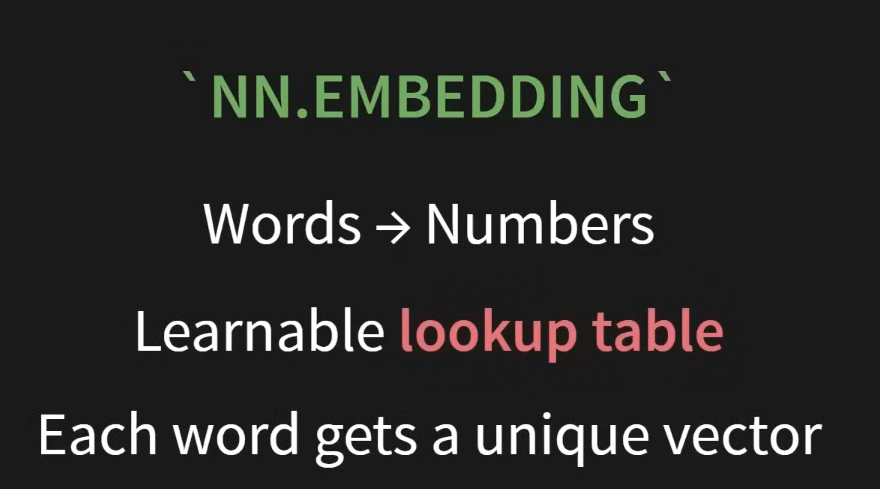

In [ ]:
vocab_size = 10_000   # 10,000 unique tokens in our vocabulary
embed_dim  = 64       # each token becomes a 64-dimensional vector

embedding_layer = nn.Embedding(
    num_embeddings=vocab_size,
    embedding_dim=embed_dim,
    padding_idx=0      # token ID 0 is <PAD>; its embedding is always zeros (frozen)
)

# Simulate a batch of 2 sentences, each 5 tokens long
# (In practice these come from a tokenizer like tiktoken or HuggingFace's AutoTokenizer)
token_ids = torch.tensor([
    [101,  23,  567,  8,  902],   # sentence 1: 5 token IDs
    [  0, 234, 1024, 99,   45],   # sentence 2: 5 token IDs (starts with PAD=0)
])   # shape: (batch=2, seq_len=5)

embedded = embedding_layer(token_ids)   # index lookup → no matmul needed

print(f"Token IDs shape:  {token_ids.shape}")    # (2, 5)
print(f"Embedded shape:   {embedded.shape}")     # (2, 5, 64)
print(f"PAD row (all 0s): {embedded[1, 0, :5]}")  # first token of sentence 2 was PAD

# Under the hood, Embedding stores a weight matrix:
print(f"\nEmbedding weight matrix shape: {embedding_layer.weight.shape}")
# (10000, 64) — vocab_size rows × embed_dim cols

# To get the vocab size and embed_dim back from a trained model:
print(f"vocab_size = {embedding_layer.num_embeddings}")
print(f"embed_dim  = {embedding_layer.embedding_dim}")

Embedding Layer's Weight Matrix (shape torch.Size([10, 3])):
 tensor([[ 0.3423,  0.4692, -0.4257],
        [-1.3365, -1.2143,  0.1631],
        [ 0.0219,  0.7079, -1.3068],
        [ 0.8212,  0.8327,  1.7456],
        [ 0.0290, -1.6448,  0.3504],
        [-0.5394,  0.0455,  0.2827],
        [-0.6848, -0.6217,  0.1016],
        [ 0.3661,  0.2408,  0.6074],
        [ 1.4495, -0.7080, -0.4682],
        [-0.2240, -0.9332, -0.0570]])

Input Token IDs (shape torch.Size([1, 4])):
 tensor([[1, 5, 0, 8]])

Output Word Vectors (shape torch.Size([1, 4, 3])):
 tensor([[[-1.3365, -1.2143,  0.1631],
         [-0.5394,  0.0455,  0.2827],
         [ 0.3423,  0.4692, -0.4257],
         [ 1.4495, -0.7080, -0.4682]]], grad_fn=<EmbeddingBackward0>)


### `nn.LayerNorm` — Keeping Numbers in Check

**Why it exists:** Deep networks suffer from "internal covariate shift" — the distribution of activations shifts unpredictably as data flows through layers, making training slow or unstable. LayerNorm fixes each sample individually so its features always have mean≈0 and std≈1.

**LayerNorm vs BatchNorm:**
| | LayerNorm | BatchNorm |
|---|---|---|
| Normalizes over | **Features** (per sample) | **Batch** (per feature) |
| Works with batch size 1? | ✅ Yes | ❌ No |
| Used in | Transformers, LLMs | CNNs, older vision models |
| Sensitive to batch size? | No | Yes |

> **Rule of thumb:** If you're building anything with sequences (NLP, speech), use `LayerNorm`. If you're building a CNN, `BatchNorm` is the classic choice.

**Formula:** $\hat{x} = \frac{x - \mu}{\sigma + \epsilon} \cdot \gamma + \beta$, where $\gamma$ and $\beta$ are learned scale and shift parameters.

**Interview Q: Why does LayerNorm have learnable parameters ($\gamma$, $\beta$)?**
> After normalizing to mean=0, std=1, the model might need a DIFFERENT scale/shift. $\gamma$ and $\beta$ let the network un-normalize if needed — they're initialized to $\gamma=1$, $\beta=0$ (identity) and learned during training.

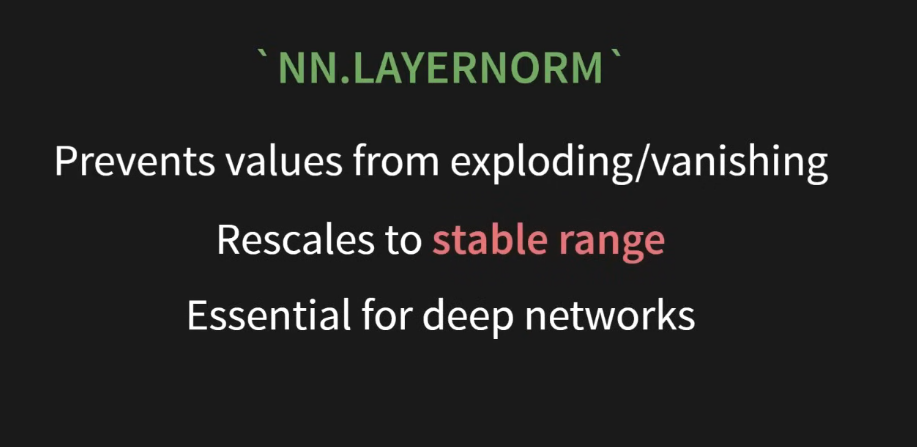

In [ ]:
embed_dim = 64

layer_norm = nn.LayerNorm(embed_dim)   # normalizes the last dimension

# Simulate ONE token's embedding vector — raw activations from a previous layer
# (these could be wildly different magnitudes in practice)
x = torch.randn(2, 5, embed_dim) * 100   # batch=2, seq=5, features=64 — large values

normalized = layer_norm(x)

print(f"Input  — mean: {x.mean():.4f},      std: {x.std():.4f}")
print(f"Output — mean: {normalized.mean():.4f}, std: {normalized.std():.4f}")
# After LayerNorm: mean ≈ 0, std ≈ 1 (not exactly because of gamma/beta)

# Check per-sample normalization (not across the batch)
print(f"\nPer-sample mean (sample 0, token 0): {normalized[0, 0].mean():.6f}")
print(f"Per-sample std  (sample 0, token 0): {normalized[0, 0].std():.6f}")

# LayerNorm has learnable parameters — gamma (weight) and beta (bias)
print(f"\nLearnable gamma (weight) shape: {layer_norm.weight.shape}")  # (64,)
print(f"Learnable beta  (bias)   shape: {layer_norm.bias.shape}")      # (64,)
print(f"gamma init value: {layer_norm.weight[0].item():.1f}")   # starts at 1.0
print(f"beta  init value: {layer_norm.bias[0].item():.1f}")     # starts at 0.0

# Shape doesn't change — LayerNorm is a "shape-preserving" operation
print(f"\nInput shape:  {x.shape}")
print(f"Output shape: {normalized.shape}")

Input Features:
 tensor([[[1., 2., 3.],
         [4., 5., 6.]]])

Normalized Features:
 tensor([[[-1.2247,  0.0000,  1.2247],
         [-1.2247,  0.0000,  1.2247]]], grad_fn=<NativeLayerNormBackward0>)

Mean of each output vector (should be ~0): tensor([[0., 0.]], grad_fn=<MeanBackward1>)
Std Dev of each output vector (should be ~1): tensor([[1.2247, 1.2247]], grad_fn=<StdBackward0>)


### `nn.Dropout` — Forcing the Network to be Robust

**What it does:** During training, randomly sets a fraction of activations to **zero** and scales the rest up to keep the expected sum the same. This prevents neurons from co-adapting and forces the network to learn redundant representations.

**Analogy:** Imagine training a sports team where random players sit out each practice. The team can't rely on any one player — everyone must learn to play every role. This makes the team (network) much more robust.

**Key parameters:**
| Parameter | Meaning |
|---|---|
| `p=0.1` | 10% of neurons zeroed randomly per forward pass |
| `p=0.5` | 50% — aggressive regularization (classic setting) |
| `p=0.0` | No dropout (effectively disables it) |

**CRITICAL behavior difference: `model.train()` vs `model.eval()`**
- In **training mode** → dropout is ACTIVE (neurons randomly dropped)
- In **eval mode** → dropout is DISABLED (all neurons active, no randomness)

> This is why you MUST call `model.eval()` before inference, and `model.train()` before training loops. Forgetting `model.eval()` during validation is a common bug that makes your model look worse than it is.

**Where used in Transformers:** After attention weights, after FFN sublayers — typically `p=0.1` in production models (GPT-2, BERT).

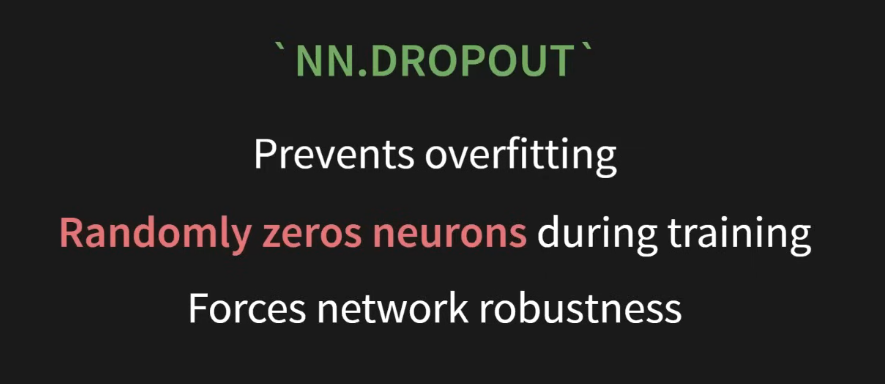

In [ ]:
dropout = nn.Dropout(p=0.3)   # 30% of values will be zeroed during training

# Sample tensor (could be the output of a Linear layer or attention block)
x = torch.ones(3, 5)   # all ones so we can see the zeroing clearly

# ── TRAINING MODE (default) ──────────────────────────────────────────
dropout.train()   # ensure we're in training mode
out_train = dropout(x)
print("Training mode output (zeros appear):")
print(out_train)
# Non-zero values are scaled UP by 1/(1-p) = 1/0.7 ≈ 1.4286
# This "inverted dropout" keeps the expected sum the same (no rescaling needed at test time)

# ── EVAL MODE ────────────────────────────────────────────────────────
dropout.eval()    # switch to evaluation mode
out_eval = dropout(x)
print("\nEval mode output (no dropout — all ones):")
print(out_eval)
# In eval mode: dropout is completely bypassed, output == input

# PRACTICAL PATTERN — always use .train() / .eval() in your loops:
# for epoch in range(epochs):
#     model.train()
#     for X_batch, y_batch in train_loader:
#         loss = criterion(model(X_batch), y_batch)
#         ...
#
#     model.eval()
#     with torch.no_grad():                        # no gradients in eval
#         for X_val, y_val in val_loader:
#             val_loss = criterion(model(X_val), y_val)

print(f"\np parameter: {dropout.p}")
print("Non-zero count training:", (out_train != 0).sum().item(), "out of", x.numel())
print("Non-zero count eval:    ", (out_eval  != 0).sum().item(), "out of", x.numel())

Input Tensor:
 tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])

Output during training (randomly zeroed and scaled):
 tensor([[0., 0., 2., 2., 2., 0., 0., 2., 0., 2.]])

Output during evaluation (identity function):
 tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])


**Note:** `nn.Dropout` uses "inverted dropout" — during training, surviving activations are scaled by $\frac{1}{1-p}$ to compensate for the dropped ones. This means at test time you can use the output as-is with no adjustment needed. This is the default PyTorch behavior and what virtually all modern frameworks use.

---
## Part 8 Interview Cheatsheet — `nn` Layers

### Quick-Reference Table
| Layer | Key Shape | Core Purpose | Interview Trap |
|---|---|---|---|
| `nn.Linear(in, out)` | `(*, in) → (*, out)` | Weighted sum + bias | Stores W transposed — weight is `(out, in)`, not `(in, out)` |
| `nn.ReLU()` | shape-preserving | Kill negative activations | Dead ReLU problem when LR is too high — use GELU for LLMs |
| `nn.GELU()` | shape-preserving | Smooth ReLU for Transformers | GPT/BERT/T5 all use GELU, not ReLU |
| `nn.Softmax(dim=-1)` | shape-preserving | Logits → probabilities | **Never** pass softmax output to `CrossEntropyLoss` — double-softmax bug! |
| `nn.Embedding(V, D)` | `(B, T) → (B, T, D)` | Token ID → dense vector | Mathematically = linear layer on one-hot, but 10,000x faster (lookup vs matmul) |
| `nn.LayerNorm(D)` | shape-preserving | Normalize features per sample | Use for sequences; BatchNorm requires large batches, LayerNorm doesn't |
| `nn.Dropout(p)` | shape-preserving | Regularization during training | **MUST** call `model.eval()` for inference — dropout is active in train mode! |

---

### Key Interview Q&A

**Q: Why does `nn.Linear` store weights as `(out_features, in_features)`?**
> To make the forward pass `x @ W.T + b` a standard matrix multiply. The transposition happens implicitly, so `out = x @ linear.weight.T + linear.bias`.

**Q: What's the difference between `ReLU` and `GELU`?**
> ReLU is `max(0, x)` — hard zero for all negative values. GELU is smooth and can pass small negative values through (weighted by their probability of being positive). GELU trains better in deep Transformer networks. When asked in an LLM context, always say GELU.

**Q: The CrossEntropyLoss + Softmax double-application bug — explain it?**
> `nn.CrossEntropyLoss` internally does: `log_softmax(input) → negative_log_likelihood`. If you manually apply `softmax` first and then pass to `CrossEntropyLoss`, you apply softmax twice → the gradients are wrong and your model won't train properly. Always pass **raw logits** to `CrossEntropyLoss`.

**Q: `nn.Embedding` vs `nn.Linear` — what's the difference conceptually?**
> Both are lookup tables, but `nn.Embedding` is optimized for **integer index → row lookup** while `nn.Linear` expects **float vectors → matrix multiply**. Embedding is also memory-efficient because it only updates the accessed rows' gradients (sparse gradients).

**Q: What's the difference between `LayerNorm` and `BatchNorm`?**
> BatchNorm normalizes across the BATCH dimension (per-feature). LayerNorm normalizes across the FEATURE dimension (per-sample). BatchNorm fails at batch_size=1; LayerNorm works perfectly. LLMs always use LayerNorm because sequence lengths and batch sizes vary.

**Q: You forgot to call `model.eval()` before computing validation loss. What happens?**
> Dropout randomly zeros neurons → validation loss will be noisier and slightly HIGHER than it should be (you're penalizing the model unfairly). Also, if BatchNorm is used, it'll update its running statistics with validation data — data leakage! Always call `model.eval()` + `torch.no_grad()` before any inference.

---
*End of Part 8 — Next: Part 9 (Building Real Models with `nn.Module` and `torch.optim`)*

# Part 9: Building Real Models with `nn.Module` and `torch.optim`

So far we've been building everything by hand: manually defining weights as tensors with `requires_grad=True`, manually computing the forward pass, manually calling `loss.backward()`, and manually updating weights with `w -= lr * w.grad`.

That approach teaches you HOW things work. But for real models — even simple ones — you need PyTorch's proper abstractions:

| Problem with manual approach | PyTorch solution |
|---|---|
| Parameters scattered as loose variables | `nn.Module` organizes them into a class |
| Manual `w -= lr * w.grad` update rule | `torch.optim` handles update strategy (SGD, Adam, etc.) |
| Can't save/load model as a checkpoint | `module.state_dict()` serializes all parameters |
| Hard to switch between train/eval | `model.train()` / `model.eval()` method |
| Can't use GPU trivially | `model.to(device)` moves ALL parameters at once |

**Core concept:** Every PyTorch model is a class that inherits from `nn.Module`. You define `__init__` (build layers) and `forward` (define how data flows through them). That's it — PyTorch handles the rest.

> **Interview tip:** Be able to write a simple `nn.Module` subclass from memory. Interviewers love asking candidates to implement a 2-layer MLP or a simplified attention head from scratch.

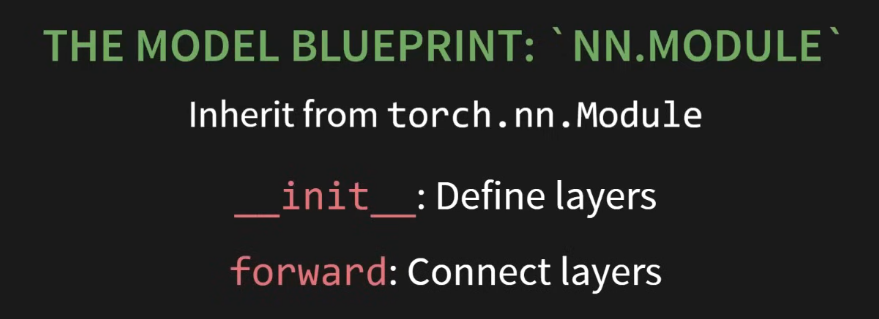

In [ ]:
import torch
import torch.nn as nn

# ──────────────────────────────────────────────────────────────────────────────
# Every PyTorch model is a class that inherits from nn.Module
# Rule 1: always call super().__init__() first in __init__
# Rule 2: define ALL layers / parameters in __init__ (not in forward!)
# Rule 3: forward() defines the computation — don't call it directly, use model(x)
# ──────────────────────────────────────────────────────────────────────────────

class LinearRegressionModel(nn.Module):

    def __init__(self):
        super().__init__()
        # nn.Linear(in_features=1, out_features=1) → learns y = W*x + b
        # PyTorch auto-registers this as a parameter of the module
        self.linear = nn.Linear(in_features=1, out_features=1)

    def forward(self, x):
        # This is CALLED when you do model(x) — NOT model.forward(x)
        # (calling model(x) goes through extra hooks PyTorch needs)
        return self.linear(x)


# Instantiate the model
model = LinearRegressionModel()

# Inspect what's inside
print("Model architecture:")
print(model)

print("\nLearnable parameters:")
for name, param in model.named_parameters():
    print(f"  {name}: shape={param.shape}, requires_grad={param.requires_grad}")

# Total number of trainable parameters:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params}")
# Output: 2 (weight: 1 float, bias: 1 float)

# state_dict() — all parameters as an ordered dictionary (used for saving/loading)
print("\nstate_dict:")
for key, val in model.state_dict().items():
    print(f"  {key}: {val}")

Model Architecture:
LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

Model Parameters:
linear_layer.weight: tensor([[0.0333]])
linear_layer.bias: tensor([0.9737])


## 9.2 The Optimizer — Replacing Manual Gradient Updates

Previously we updated weights manually:
```python
with torch.no_grad():
    w -= lr * w.grad
    b -= lr * b.grad
    w.grad.zero_()
    b.grad.zero_()
```

This works for simple cases, but:
- It only implements vanilla SGD — no momentum, no adaptive learning rates
- You have to manually track **every** parameter
- You have to manually zero every gradient

`torch.optim` replaces all of this with one object. Popular optimizers:

| Optimizer | When to use | Key idea |
|---|---|---|
| `SGD` | When you want full control; convex problems | Pure gradient descent (+ optional momentum) |
| `Adam` | Best default for deep learning | Adaptive LR per parameter + momentum |
| `AdamW` | Modern LLM standard (GPT, BERT, LLaMA) | Adam + proper weight decay (L2 reg) |
| `RMSProp` | RNNs, RL | Adaptive LR without momentum |

> **Interview tip:** Know WHY Adam beats SGD by default: Adam maintains per-parameter learning rates that adapt based on gradient history. Parameters with small/rare gradients (like rare tokens' embeddings) get larger updates. Parameters with large/frequent gradients get smaller updates. This makes training much more stable.

### Replacing Manual Updates with `torch.optim`

**Three-line replacement:**

| Manual (what we did) | Professional (what you use in production) |
|---|---|
| `w -= lr * w.grad` | `optimizer.step()` |
| `w.grad.zero_()` | `optimizer.zero_grad()` |
| (track params yourself) | `optimizer = Adam(model.parameters(), lr=...)` |

The optimizer holds a **reference** to `model.parameters()` — it doesn't copy them. When you call `optimizer.step()`, it reads the `.grad` attribute on each parameter and applies the update rule (SGD, Adam, etc.) in-place.

In [ ]:
import torch.optim as optim

# ── SGD (Stochastic Gradient Descent) ─────────────────────────────────────────
optimizer_sgd = optim.SGD(
    model.parameters(),   # reference to all nn.Module parameters
    lr=0.01,               # learning rate
    momentum=0.9          # helps escape local minima (most common in practice)
)

# ── Adam (Adaptive Moment Estimation) ──────────────────────────────────────────
optimizer_adam = optim.Adam(
    model.parameters(),
    lr=1e-3,              # 0.001 is the standard default
    betas=(0.9, 0.999),   # β1=momentum decay, β2=sq-gradient decay (rarely changed)
    eps=1e-8,             # numerical stability (rarely changed)
    weight_decay=0.0      # L2 penalty (add e.g. 1e-4 to fight overfitting)
)

# ── AdamW (Adam + proper weight decay) ─────────────────────────────────────────
# USE THIS for LLMs and Transformers — it's what GPT/BERT/LLaMA use
optimizer_adamw = optim.AdamW(
    model.parameters(),
    lr=1e-4,              # LLMs typically use smaller LR (3e-4 to 1e-5)
    weight_decay=0.01     # standard L2 regularization in Transformers
)

print("SGD:", optimizer_sgd)
print("\nAdam:", optimizer_adam)
print("\nAdamW:", optimizer_adamw)

# You can also pass different LRs to different parameter groups:
# optimizer = Adam([
#     {'params': model.encoder.parameters(), 'lr': 1e-5},   # pretrained → small LR
#     {'params': model.head.parameters(),    'lr': 1e-3}    # new head  → large LR
# ])

## 9.3 The Final Clean Training Loop

Now we combine `nn.Module` + `torch.optim` into the professional training loop that you'll use in EVERY real project.

The anatomy of every PyTorch training loop is ALWAYS these 5 steps inside a for loop:

```
for epoch in range(epochs):
    1. Forward pass  →  predictions = model(X)
    2. Compute loss  →  loss = criterion(predictions, y)
    3. Zero grads    →  optimizer.zero_grad()
    4. Backward pass →  loss.backward()
    5. Update weights→  optimizer.step()
```

> **Why zero_grad() comes BEFORE backward() (step 3 before 4)?**
> Because PyTorch accumulates gradients by default. If you don't zero first, gradients from the previous batch add onto the current batch's gradients — giving you the wrong update direction. Always zero before you compute new grads.

### The Three-Line Mantra

Every PyTorch training step reduces to these three lines (steps 3-5):

```python
optimizer.zero_grad()   # clear old gradients
loss.backward()         # compute new gradients (backprop)
optimizer.step()        # update parameters
```

Memorize this order. You'll type it thousands of times in your career.

> **A common bug:** Calling `optimizer.step()` BEFORE `loss.backward()`. The optimizer has no gradients to read yet — it'll silently update with whatever garbage was in `.grad` from the last step (or zero if first step). Your model will still "train" but very slowly and incorrectly.

### Professional Training Loop — Complete Implementation

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# ── Reproducibility ──────────────────────────────────────────────────────
torch.manual_seed(42)

# ── 1. Generate Data (same as before: y = 2x + 1 + noise) ───────────────
N = 100                                            # number of examples
X = torch.linspace(-1, 1, N).unsqueeze(1)          # shape: (100, 1)
y = 2 * X + 1 + 0.1 * torch.randn_like(X)         # shape: (100, 1)

# ── 2. Build Model ──────────────────────────────────────────────────────
class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(1, 1)           # one input feature → one output

    def forward(self, x):
        return self.fc(x)                   # y_hat = W*x + b

model = LinearModel()

# ── 3. Loss Function & Optimizer ────────────────────────────────────────
criterion = nn.MSELoss()                    # mean squared error
optimizer = optim.Adam(model.parameters(), lr=0.05)

# ── 4. Training Loop ─────────────────────────────────────────────────────
epochs = 300

model.train()   # put model in training mode (enables dropout, batchnorm, etc.)

for epoch in range(epochs):

    # ─ Step 1: Forward pass ─────────────────────────────────────────────
    y_pred = model(X)              # model(X) calls model.forward(X) under the hood

    # ─ Step 2: Compute loss ─────────────────────────────────────────────
    loss = criterion(y_pred, y)    # scalar tensor with grad_fn

    # ─ Step 3: Zero gradients ───────────────────────────────────────────
    optimizer.zero_grad()          # MUST do this before backward() — clears .grad

    # ─ Step 4: Backward pass ────────────────────────────────────────────
    loss.backward()                # compute d(loss)/d(param) for all parameters

    # ─ Step 5: Update weights ───────────────────────────────────────────
    optimizer.step()               # Adam updates each param using its grad

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {loss.item():.6f}")

# ── 5. Inspect Learned Parameters ───────────────────────────────────────
learned_weight = model.fc.weight.item()
learned_bias   = model.fc.bias.item()
print(f"\nTrue: y = 2.0*x + 1.0")
print(f"Learned: y = {learned_weight:.4f}*x + {learned_bias:.4f}")
# Should be very close to w≈2.0, b≈1.0

# ── 6. Inference (always use eval + no_grad) ─────────────────────────────
model.eval()                                      # disable dropout, batchnorm in eval mode
with torch.no_grad():                             # don't build computation graph
    x_test = torch.tensor([[0.5]])                # what is y when x=0.5?
    y_hat  = model(x_test)
    print(f"\nPrediction at x=0.5: {y_hat.item():.4f}")
    print(f"True value at x=0.5: {2*0.5 + 1:.4f}")   # expected: 2.0

Epoch 00: Loss=2.8557, W=0.043, b=0.984
Epoch 10: Loss=2.5142, W=0.143, b=1.082
Epoch 20: Loss=2.2201, W=0.241, b=1.170
Epoch 30: Loss=1.9705, W=0.338, b=1.239
Epoch 40: Loss=1.7550, W=0.431, b=1.280
Epoch 50: Loss=1.5627, W=0.521, b=1.292
Epoch 60: Loss=1.3869, W=0.608, b=1.281
Epoch 70: Loss=1.2260, W=0.693, b=1.257
Epoch 80: Loss=1.0796, W=0.774, b=1.231
Epoch 90: Loss=0.9474, W=0.853, b=1.208


Now that we have the full training loop, let's put everything from Parts 8 and 9 together into one real neural network — a **FeedForward Network (FFN)** such as you'd find inside a Transformer block.

This FFN uses all the layers we've learned: `nn.Linear`, `nn.GELU`, `nn.LayerNorm`, `nn.Dropout` — assembled properly with `nn.Module`.

In [ ]:
import torch
import torch.nn as nn

# ──────────────────────────────────────────────────────────────────────────────
# FeedForward Network (FFN) — the sublayer used in EVERY Transformer block
#
# Architecture: Linear → GELU → Dropout → Linear → Dropout
#
# In GPT/BERT: embed_dim=768, hidden_dim=3072 (4x expansion, then contract back)
# The "4x" expansion is a design pattern from "Attention is All You Need" (2017)
# ──────────────────────────────────────────────────────────────────────────────

class FeedForwardNetwork(nn.Module):

    def __init__(self, embed_dim: int, expansion_factor: int = 4, dropout_p: float = 0.1):
        super().__init__()

        hidden_dim = embed_dim * expansion_factor   # e.g., 64 → 256

        # Layer 1: expand dimensionality
        self.fc1 = nn.Linear(embed_dim, hidden_dim)

        # Non-linearity: GELU is standard for Transformers (ReLU is for older models)
        self.gelu = nn.GELU()

        # Dropout for regularization (applied after activation)
        self.dropout1 = nn.Dropout(p=dropout_p)

        # Layer 2: contract back to original dimensionality (residual connection!)
        self.fc2 = nn.Linear(hidden_dim, embed_dim)

        # Second dropout (applied after second linear layer)
        self.dropout2 = nn.Dropout(p=dropout_p)

    def forward(self, x):
        # x shape: (batch, seq_len, embed_dim)
        out = self.fc1(x)           # (batch, seq_len, embed_dim) → (batch, seq_len, hidden_dim)
        out = self.gelu(out)        # non-linearity (no shape change)
        out = self.dropout1(out)    # regularization (only active during training)
        out = self.fc2(out)         # (batch, seq_len, hidden_dim) → (batch, seq_len, embed_dim)
        out = self.dropout2(out)    # regularization (only active during training)
        return out                  # same shape as input — ready for residual addition!


# ── Test the FFN ──
embed_dim = 64
batch, seq_len = 2, 10

ffn = FeedForwardNetwork(embed_dim=embed_dim, expansion_factor=4, dropout_p=0.1)
print(ffn)

# Random input (simulates output from attention sublayer)
x = torch.randn(batch, seq_len, embed_dim)   # (2, 10, 64)
out = ffn(x)

print(f"\nInput  shape: {x.shape}")    # (2, 10, 64)
print(f"Output shape: {out.shape}")   # (2, 10, 64) — same! Ready for residual: x + FFN(x)

# Parameter count breakdown
for name, p in ffn.named_parameters():
    print(f"  {name:20s}  {p.shape}  params={p.numel():,}")

total = sum(p.numel() for p in ffn.parameters())
print(f"\nTotal FFN parameters: {total:,}")
# fc1: 64×256 + 256 = 16,640  |  fc2: 256×64 + 64 = 16,448  |  Total ≈ 33,088

---
## Part 9 Interview Cheatsheet — `nn.Module` & `torch.optim`

### Core Concepts Recap

**`nn.Module` rules:**
1. All custom models MUST inherit from `nn.Module`
2. `__init__`: define layers (they get auto-registered as parameters)
3. `forward`: define the computation graph (called as `model(x)`, NOT `model.forward(x)`)
4. Never define learnable tensors as plain `torch.tensor` in `__init__` — use `nn.Parameter` or `nn.Linear`/other layers so they're tracked

**`torch.optim` rules:**
1. Create optimizer with `optimizer = optim.Adam(model.parameters(), lr=...)`
2. The THREE-LINE MANTRA is ALWAYS: `zero_grad()` → `backward()` → `step()`
3. `model.train()` before training loop, `model.eval()` + `torch.no_grad()` before evaluation

---

### Quick-Reference Q&A

**Q: Why call `model(x)` instead of `model.forward(x)`?**
> `model(x)` goes through `nn.Module.__call__` which runs hooks (forward/backward hooks used by profilers, debuggers, gradient monitoring). Always use `model(x)`.

**Q: What does `model.parameters()` return?**
> A generator of all leaf tensors with `requires_grad=True` that are registered as part of the module (via `nn.Linear`, `nn.Embedding`, or `nn.Parameter`). It recursively finds parameters in sub-modules too.

**Q: Difference between `model.state_dict()` and `model.parameters()`?**
> `state_dict()` returns an OrderedDict of named tensors (both parameters AND buffers like BatchNorm running mean). Used for saving/loading. `parameters()` returns only learnable parameters (no buffers). Use `state_dict` for checkpointing.

**Q: How do you save and load a model checkpoint?**
```python
# Save
torch.save(model.state_dict(), 'model.pth')

# Load
model = MyModel()
model.load_state_dict(torch.load('model.pth'))
model.eval()
```
> Never save the entire model with `torch.save(model, ...)` — it breaks if you rename the class. Always save/load `state_dict()`.

**Q: What is `SGD` vs `Adam` vs `AdamW`?**
> - **SGD**: Pure gradient descent (+ optional momentum). Slower convergence but sometimes finds sharper minima that generalize better.
> - **Adam**: Adaptive LR per parameter. Fast convergence. Default choice for most tasks.
> - **AdamW**: Adam with CORRECT weight decay (L2 reg). Adam's built-in `weight_decay` is broken — it applies L2 to the adaptive LR, not directly to weights. AdamW fixes this. **Use AdamW for LLMs and Transformers.**

**Q: What is gradient accumulation? Why is it useful?**
> Instead of calling `optimizer.step()` after every batch, you accumulate gradients over N batches before stepping. This simulates a larger effective batch size without needing more GPU memory:
```python
accumulation_steps = 4
for i, (X_batch, y_batch) in enumerate(loader):
    loss = criterion(model(X_batch), y_batch) / accumulation_steps
    loss.backward()                        # accumulates gradients
    if (i + 1) % accumulation_steps == 0:
        optimizer.step()                   # update after N batches
        optimizer.zero_grad()              # now zero
```

**Q: What's the FeedForward Network in a Transformer, and why the 4x expansion?**
> The FFN is `Linear(d→4d) → GELU → Linear(4d→d)`. The 4x expansion gives the network extra "working memory" to perform more complex transformations. After the expansion, it contracts back so the output can be added as a residual. The 4x factor is from "Attention is All You Need" — empirically it works well and has become standard.

---
*End of Part 9 — Next: Part 10 (The Big Picture: How LLMs Scale Up)*

# Part 10: The Big Picture — How Modern LLMs Scale Up

You've learned all the building blocks. Now let's understand how they fit together into the systems that power GPT, Claude, LLaMA, and BERT.

The shocking fact: **a GPT-3 scale model (175 billion parameters) is just ~96 copies of essentially the same structure you've already learned**, stacked together.

Each "Transformer block" = LayerNorm → MultiHeadAttention → residual add → LayerNorm → FFN → residual add

And the full LLM = Embedding + positional encoding + N×TransformerBlock + final LayerNorm + output Linear.

| Component | What we learned | LLM-scale version |
|---|---|---|
| `nn.Embedding` | Part 8 | Token + positional embeddings |
| `nn.Linear` | Part 8 | Q, K, V projections; FFN layers |
| `nn.GELU` | Part 8 | FFN activation in every block |
| `nn.LayerNorm` | Part 8 | Pre-norm in every block |
| `nn.Dropout` | Part 8 | Regularization throughout |
| Training loop | Part 9 | Same loop! Just millions of batches |
| `nn.Module` | Part 9 | Every Transformer block is a module |

**What we haven't covered (attention mechanism):**
> Multi-Head Self-Attention is the missing piece — but it too uses only `nn.Linear` internally (Q, K, V, output projections). The magic is in how they're combined with `torch.softmax` and `torch.bmm`. This is the one major concept beyond this notebook's scope.

> **Interview takeaway:** You can implement a fully functional LLM using ONLY the concepts in this notebook + attention. Companies like Karpathy (nanoGPT) have done it in ~300 lines of PyTorch.

## Putting It All Together — Your Mental Model of an LLM

Here's the complete pipeline from raw text to predicted next token:

```
Input text: "The cat sat on the"
       ↓  tokenizer  
Token IDs: [464, 3797, 3332, 319, 262]     shape: (1, 5)
       ↓  nn.Embedding
Token vectors: shape (1, 5, 768)             — each token is now a 768-dim float vector
       ↓  + positional encoding
With position info: shape (1, 5, 768)        — model now knows token ORDER
       ↓  × N Transformer Blocks (e.g., 12 for GPT-2 small, 96 for GPT-3)
         Each block:
           LayerNorm → MultiHeadAttention → residual add
           LayerNorm → FeedForward (Linear→GELU→Linear) → residual add
         Output shape: UNCHANGED (1, 5, 768)  — shape-preserving all the way
       ↓  final LayerNorm
       ↓  nn.Linear(768, vocab_size=50257)     — "unembedding" back to vocabulary
Logits shape: (1, 5, 50257)                    — raw scores for each vocab token
       ↓  softmax (or argmax for greedy decoding)
Next token probabilities: (1, 50257)           — pick the highest → "mat"!
```

**The three magic ingredients that make it all work:**
1. **Scale** — billions of parameters, trained on trillions of tokens
2. **Attention** — lets every token "look at" every other token (the one piece not in this notebook)
3. **Residual connections** — `x + sublayer(x)` — prevents gradient vanishing in deep networks

---

**You now know enough PyTorch to:**
- Implement any neural network architecture as an `nn.Module`
- Train it with any optimizer from `torch.optim`
- Use GPU acceleration with `.to(device)`
- Debug tensor shapes, dtypes, and gradient flow
- Build the FFN sublayer of a Transformer from scratch
- Understand every line of code in papers like "Attention is All You Need"

*The notebook is complete. Go build something amazing.*

---
# GRAND FINAL CHEATSHEET — Complete PyTorch Interview Reference

*This single cell summarizes everything in this notebook. Read this the morning of your interview.*

---

## Part 1 — Tensors

| Concept | Key Point |
|---|---|
| `torch.tensor(data)` | Infers dtype from Python/numpy data |
| `torch.Tensor(shape)` | Uninitialized! Use `torch.zeros/ones/randn` |
| `torch.zeros_like(x)` | Same shape/dtype/device as x — used for masks |
| `.shape` / `.dtype` / `.device` | Three attributes to ALWAYS check when debugging |
| dtype promotion | `int + float → float`; `float32 + float64 → float64` |
| `x.to('cuda')` | Moves tensor to GPU; raises error if no GPU |

---

## Part 2 — Autograd

| Concept | Key Point |
|---|---|
| `requires_grad=True` | Opt in to gradient tracking for leaf tensors |
| `loss.backward()` | Computes ALL gradients via chain rule |
| `tensor.grad` | Populated after `.backward()` — only for leaf tensors |
| `torch.no_grad()` | Inference mode — no graph built, saves memory |
| `tensor.detach()` | New tensor same data but no gradient history |
| `grad_fn` | If `None` → leaf; otherwise shows last operation |
| Calling `backward()` twice | ❌ Errors by default — use `retain_graph=True` |

---

## Part 3 — Math Operations

| Operation | Code | Interview Note |
|---|---|---|
| Element-wise multiply | `a * b` or `torch.mul(a, b)` | Requires same shape |
| Matrix multiply | `a @ b` or `torch.matmul(a, b)` | `(m,n) @ (n,p) → (m,p)` |
| Batched matmul | `torch.bmm(a, b)` | `(B,m,n) @ (B,n,p) → (B,m,p)` |
| Sum over dim | `x.sum(dim=0)` | dim=0→collapse rows; dim=1→collapse cols |
| Keep dims | `x.sum(dim=0, keepdim=True)` | Required for broadcasting to work |
| Softmax | `F.softmax(x, dim=-1)` | Apply on last dim; sums to 1.0 |

---

## Part 4 — Indexing & Gathering

| Concept | Key Point |
|---|---|
| Slicing | `x[1:3, 0:2]` — standard numpy-style |
| Boolean mask | `x[x > 0]` — filters to 1D |
| `argmax` | Index of max value; `topk` for top-k sampling in LLMs |
| `torch.gather(x, dim, idx)` | Extract specific indices — used in loss computation |
| Views vs copies | Slicing returns view; `.clone()` makes a copy |

---

## Part 5 & 6 — Forward & Backward Pass

| Concept | Key Point |
|---|---|
| Forward pass | Compute predictions: `y_pred = X @ w + b` |
| Loss | Measures prediction error (e.g., MSE, CrossEntropy) |
| `loss.backward()` | Fills `.grad` on all tensors with `requires_grad=True` |
| Gradient = direction | `.grad` points in direction of STEEPEST ASCENT; negate to descend |
| `w.grad.zero_()` | Must zero after each update or gradients accumulate |

---

## Part 7 — Training Loop

**THE FIVE STEPS (always in this order):**
1. `y_pred = model(X)` — forward pass
2. `loss = criterion(y_pred, y)` — compute loss
3. `optimizer.zero_grad()` — zero old gradients
4. `loss.backward()` — compute new gradients
5. `optimizer.step()` — update parameters

| Hyperparameter | Too small | Too large | Good range |
|---|---|---|---|
| Learning rate | Slow convergence | Divergence/oscillation | 1e-4 to 1e-2 |
| Batch size | Slow per epoch | Poor generalization | 32–256 |

---

## Part 8 — `nn` Layers

| Layer | Shape In/Out | Critical Interview Point |
|---|---|---|
| `nn.Linear(in, out)` | `(*, in) → (*, out)` | `.weight` shape is `(out, in)` — transposed |
| `nn.ReLU()` | shape-preserving | Dead ReLU problem at high LR |
| `nn.GELU()` | shape-preserving | Standard for LLMs (not ReLU) |
| `nn.Softmax(dim=-1)` | shape-preserving | NEVER pass softmax to CrossEntropyLoss! |
| `nn.Embedding(V, D)` | `(B,T) → (B,T,D)` | Fast lookup, not matmul |
| `nn.LayerNorm(D)` | shape-preserving | Per-sample norm; works at batch_size=1 |
| `nn.Dropout(p)` | shape-preserving | DISABLED in `model.eval()` — always call eval! |

---

## Part 9 — `nn.Module` & `torch.optim`

```python
# The minimal correct nn.Module pattern:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()          # ALWAYS first
        self.layer = nn.Linear(in, out)
    def forward(self, x):
        return self.layer(x)        # called as model(x), not model.forward(x)

# The THREE-LINE MANTRA (in order, every time):
optimizer.zero_grad()    # 1. clear old grads
loss.backward()          # 2. compute new grads
optimizer.step()         # 3. update weights

# Save / Load:
torch.save(model.state_dict(), 'model.pth')
model.load_state_dict(torch.load('model.pth'))

# Optimizer comparison:
# SGD   → pure GD, good baseline
# Adam  → adaptive LR, fast convergence, default
# AdamW → Adam + correct L2 reg, USE THIS for Transformers/LLMs
```

---

## Part 10 — LLM Architecture Mental Model

```
Token IDs → nn.Embedding → [+positional encoding]
         ↓  × N Transformer Blocks:
               LayerNorm → MultiHeadAttention → +residual
               LayerNorm → FFN(Linear→GELU→Linear) → +residual
         ↓  final LayerNorm
         ↓  nn.Linear(d_model → vocab_size) → logits
         ↓  softmax → next token probabilities
```

**Key numbers to know:**
| Model | Parameters | Layers | d_model | Heads |
|---|---|---|---|---|
| GPT-2 small | 117M | 12 | 768 | 12 |
| GPT-2 large | 774M | 36 | 1280 | 20 |
| GPT-3 | 175B | 96 | 12288 | 96 |
| LLaMA-7B | 7B | 32 | 4096 | 32 |

---

## Universal Interview Tips

1. **Always state tensor shapes** — interviewers love shape-aware candidates
2. **Know the 5 training steps cold** — write them from memory
3. **`model.eval()` + `torch.no_grad()` for inference** — always
4. **`CrossEntropyLoss` takes RAW logits** — never softmax first
5. **AdamW for Transformers**, Adam for everything else, SGD if you need to control LR manually
6. **Gradient accumulation** = simulate large batch with small GPU memory
7. **`state_dict()`** for saving; never `torch.save(model)` directly
8. **LayerNorm for sequences**, BatchNorm for CNNs
9. **GELU in LLMs**, ReLU in older/simpler networks
10. **`requires_grad=False`** to freeze layers during fine-tuning (LoRA, transfer learning)

---
*You are ready. Good luck!*